In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as k

import DAN_code.data_processing as data_proc
import DAN_code.initializers as init
from DAN_code import models

from tensorflow.keras.datasets import mnist

import matplotlib.pyplot as plt
import DAN_code.result_plotting as res_plot
import DAN_code.result_testing as res_test
import time

import os

eps = np.finfo("float32").eps

# %load_ext tensorboard

2025-07-07 16:32:53.193669: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 16:32:53.261460: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-07 16:32:56.633029: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Fig. 1: weights learned with supervised learning.

Epoch 1/200
54/54 [==============================] - 3s 52ms/step - loss: -4.7005 - accuracy: 0.1132 - val_loss: -4.8613 - val_accuracy: 0.1050
Epoch 2/200
54/54 [==============================] - 3s 50ms/step - loss: -5.1284 - accuracy: 0.1132 - val_loss: -5.4473 - val_accuracy: 0.1050
Epoch 3/200
54/54 [==============================] - 3s 50ms/step - loss: -5.8140 - accuracy: 0.1132 - val_loss: -6.2104 - val_accuracy: 0.1050
Epoch 4/200
54/54 [==============================] - 3s 49ms/step - loss: -6.5991 - accuracy: 0.1132 - val_loss: -6.9870 - val_accuracy: 0.1050
Epoch 5/200
54/54 [==============================] - 3s 49ms/step - loss: -7.3055 - accuracy: 0.1132 - val_loss: -7.5983 - val_accuracy: 0.1050
Epoch 6/200
54/54 [==============================] - 3s 49ms/step - loss: -7.8138 - accuracy: 0.1132 - val_loss: -8.0061 - val_accuracy: 0.1050
Epoch 7/200
54/54 [==============================] - 3s 48ms/step - loss: -8.1447 - accuracy: 0.1132 - val_loss: -8.2680 - val_accuracy:

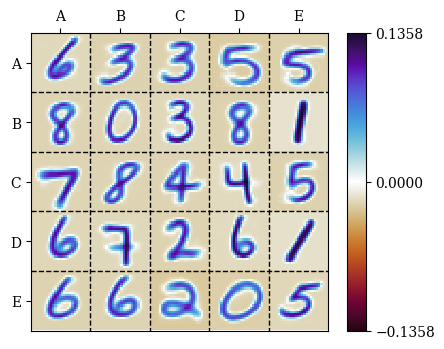

1/1 [==============================] - 0s 109ms/step


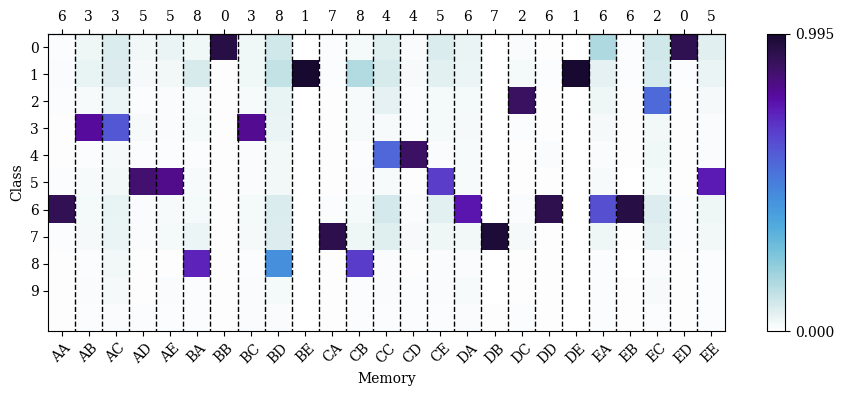

32/32 [==============================] - 0s 2ms/step


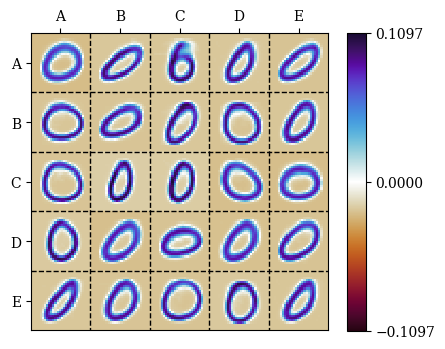

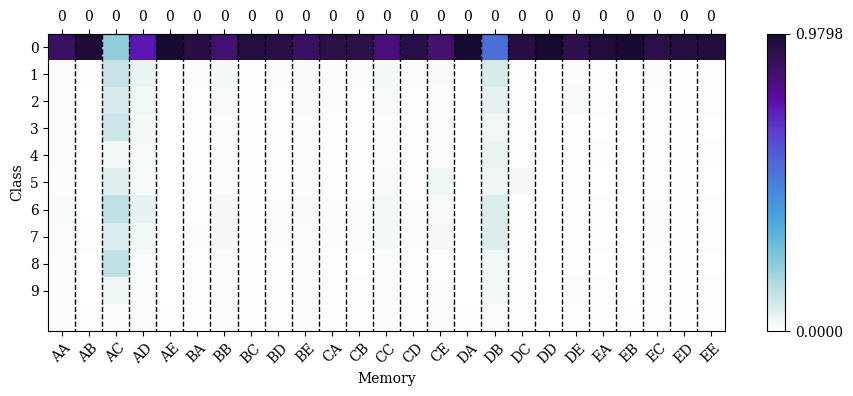

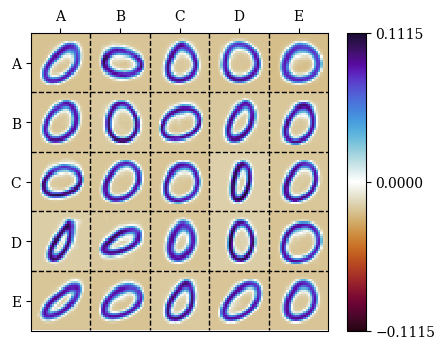

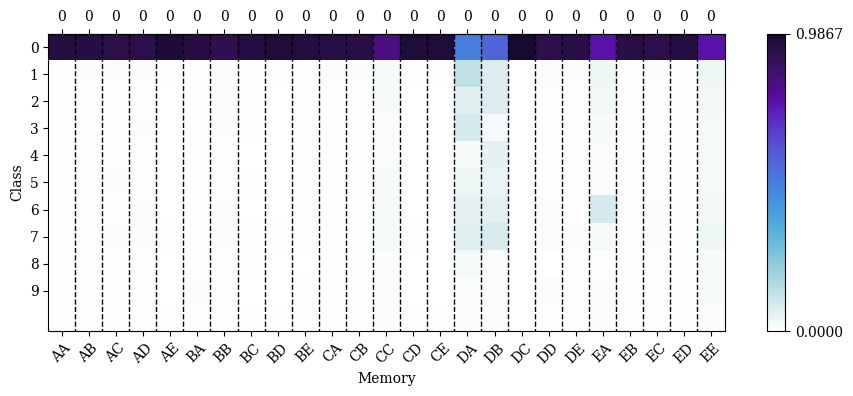

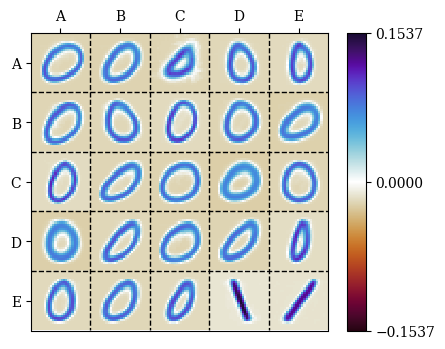

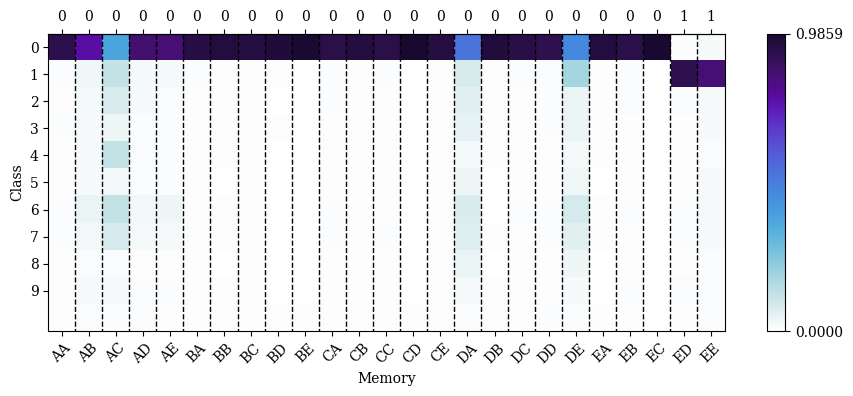

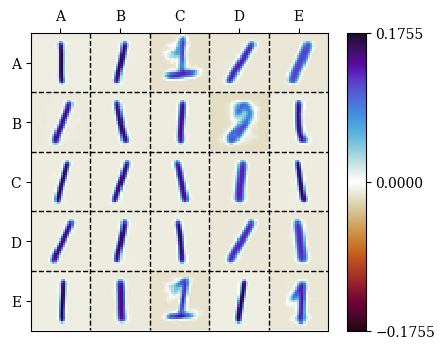

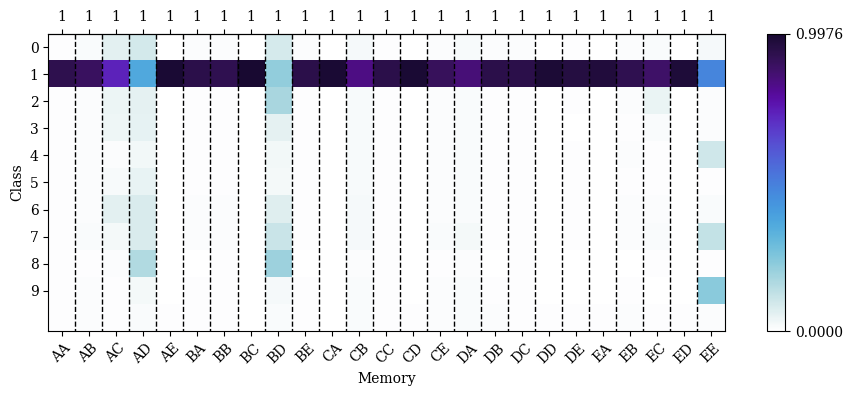

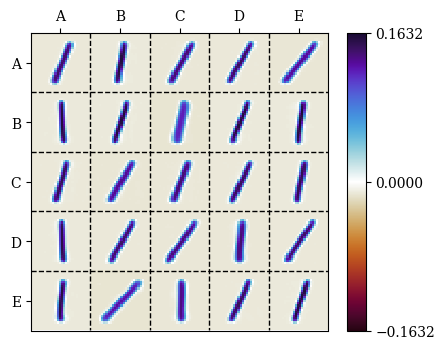

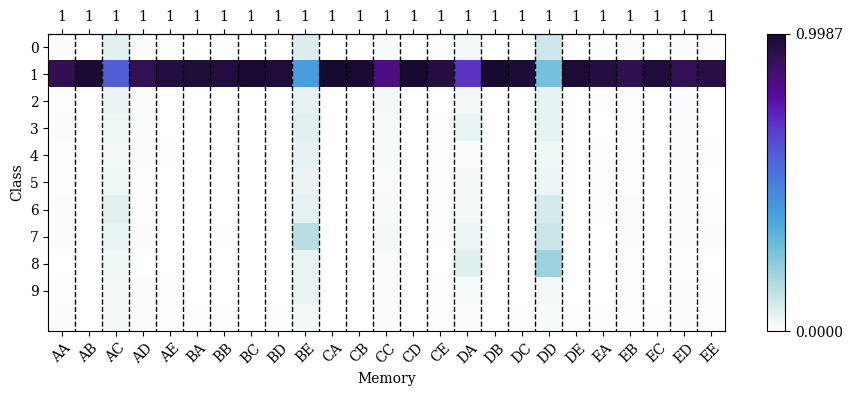

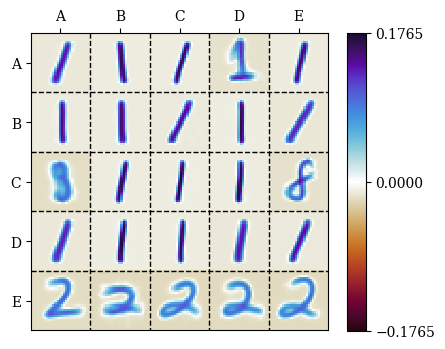

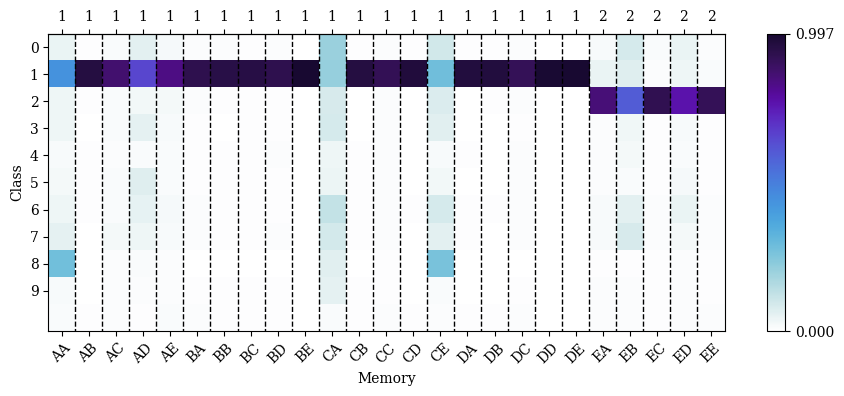

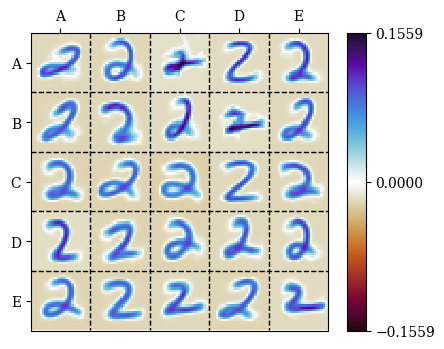

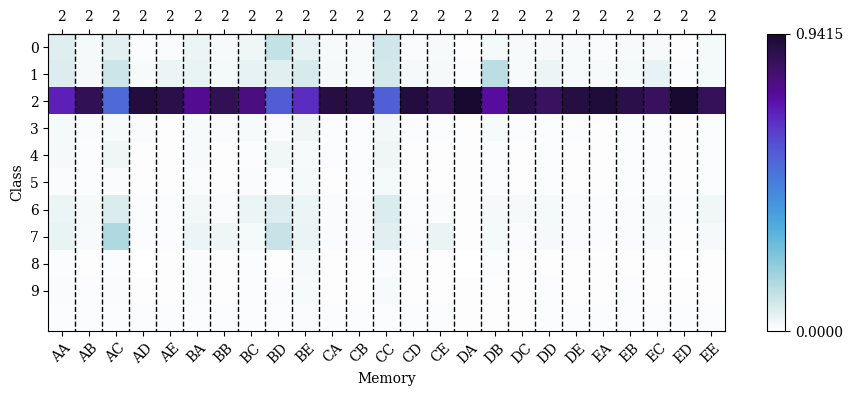

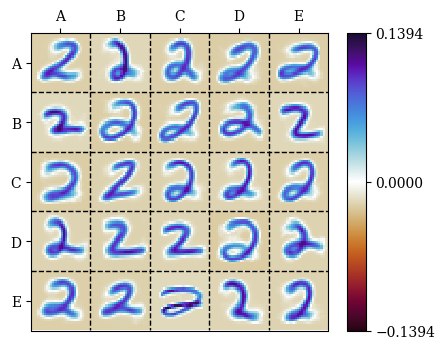

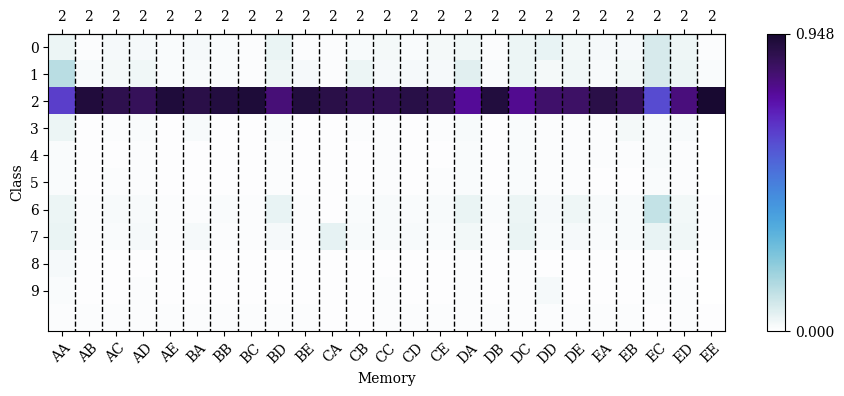

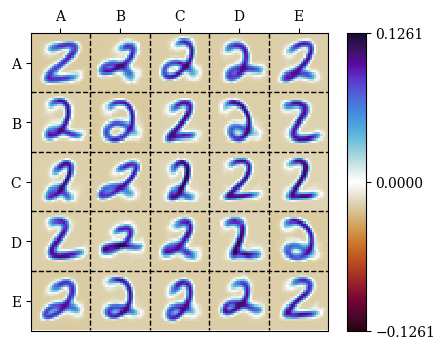

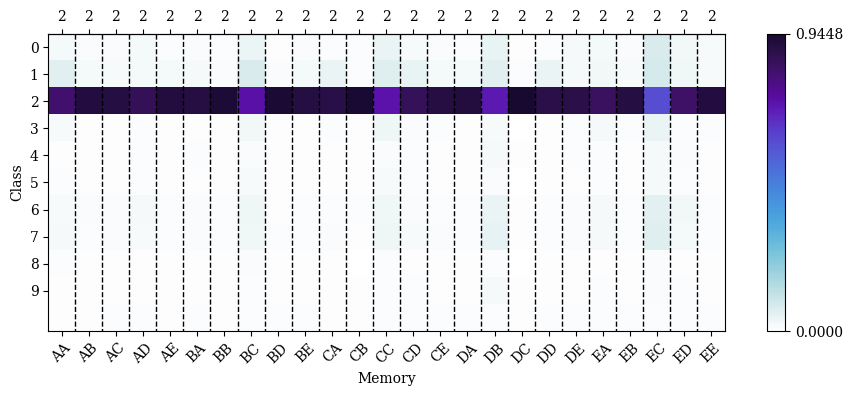

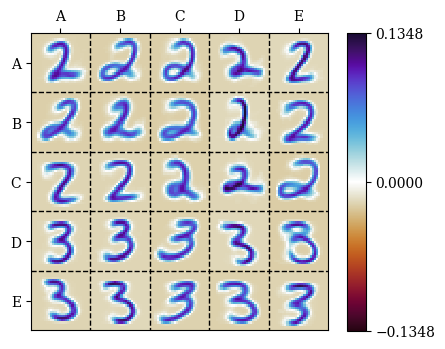

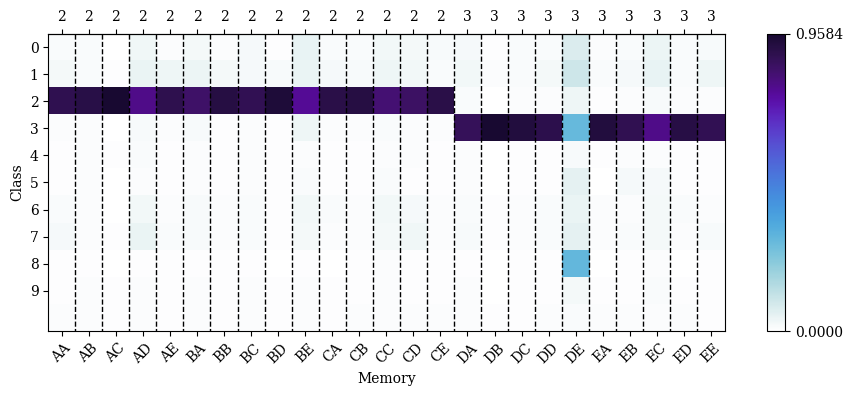

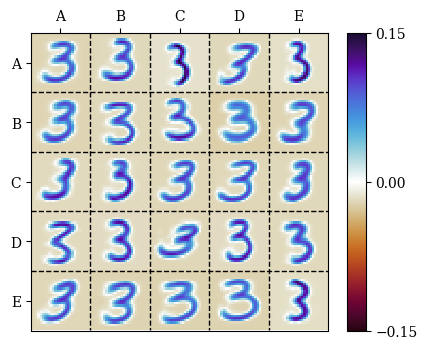

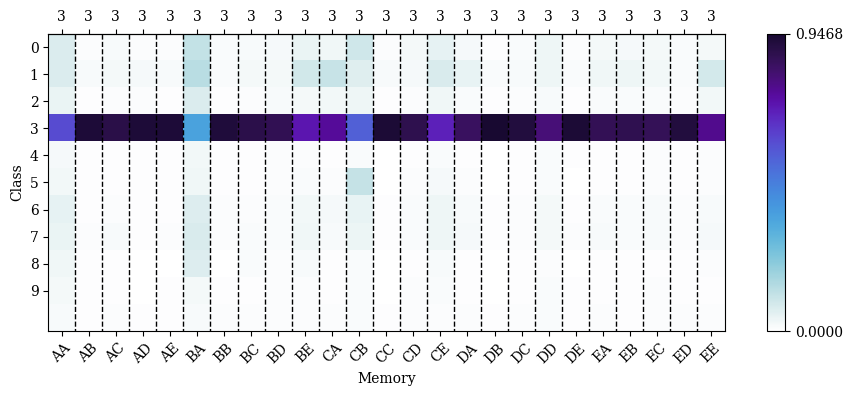

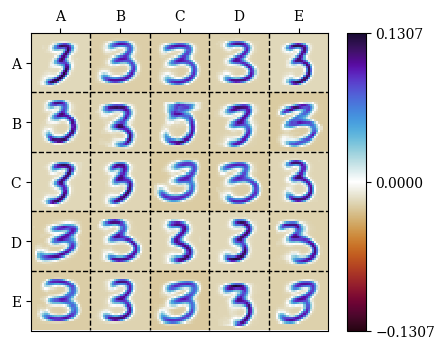

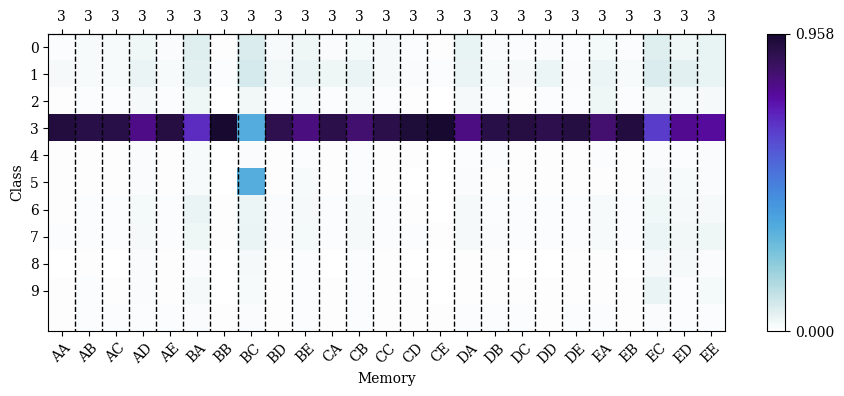

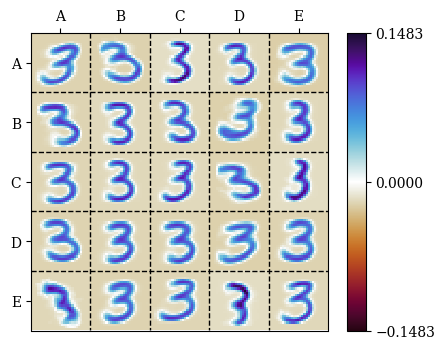

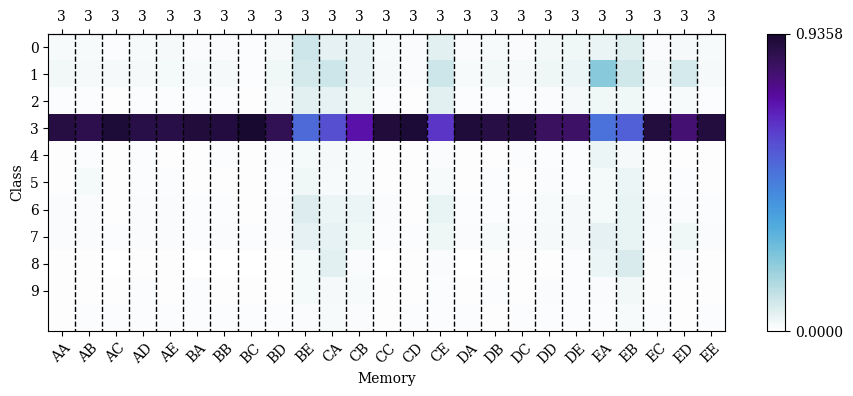

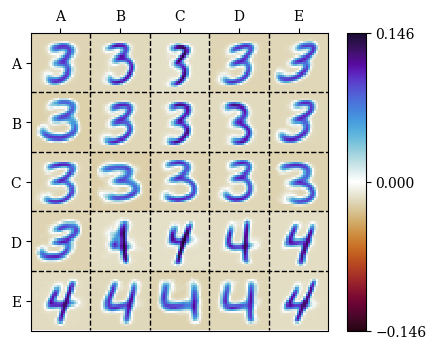

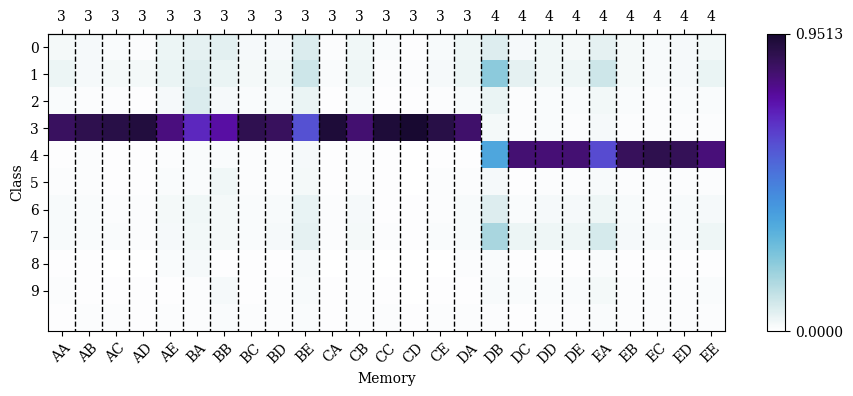

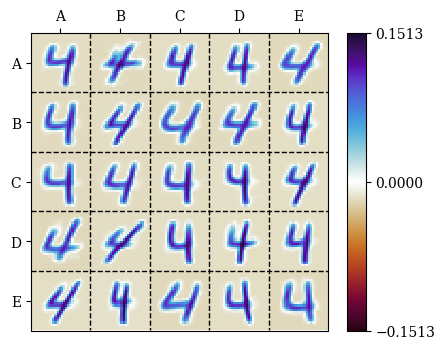

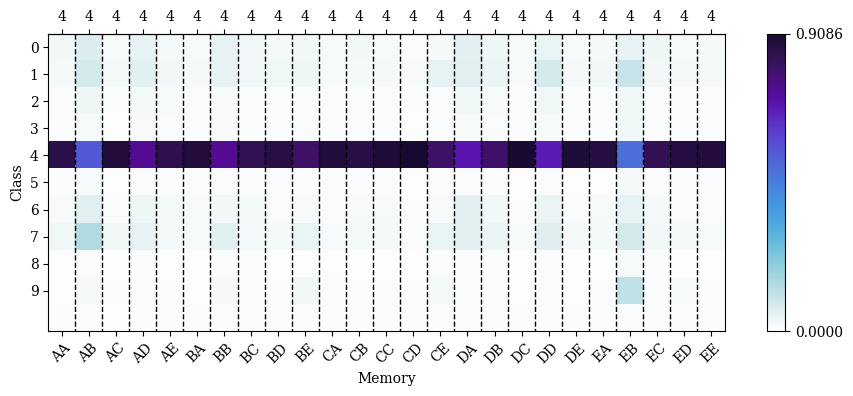

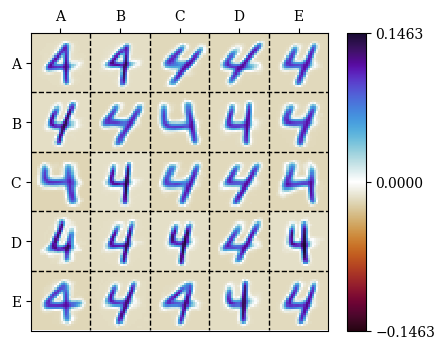

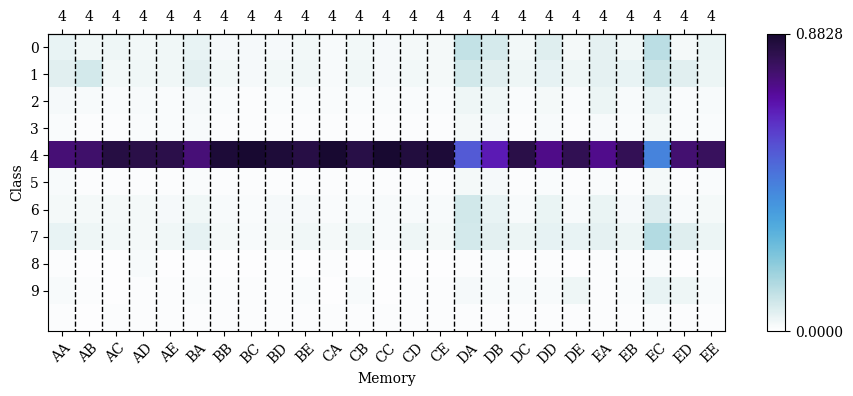

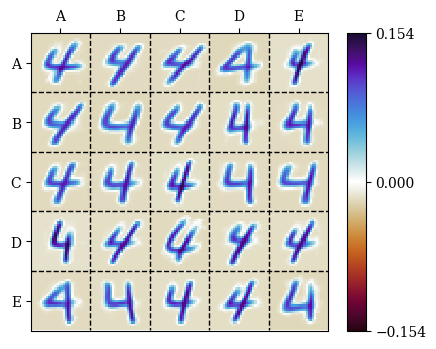

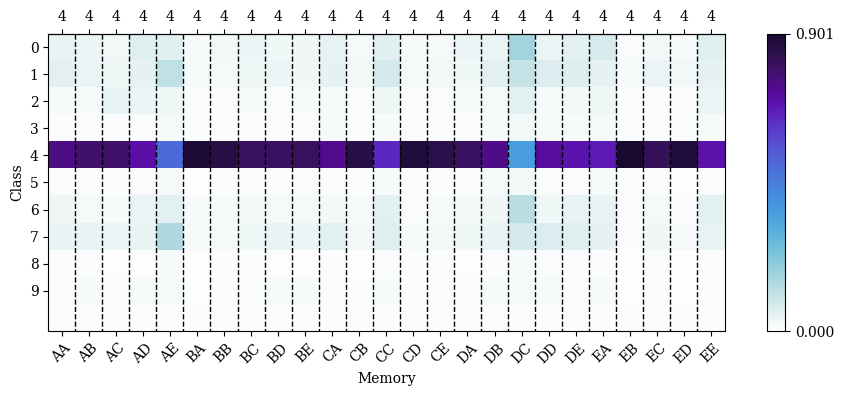

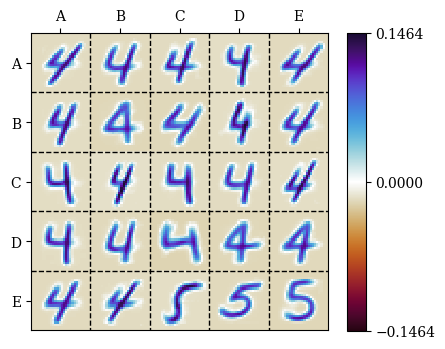

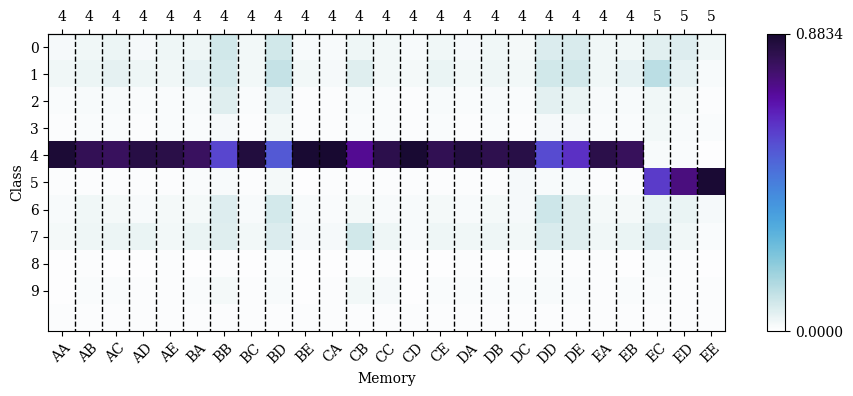

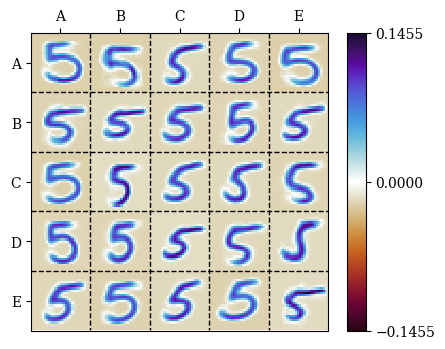

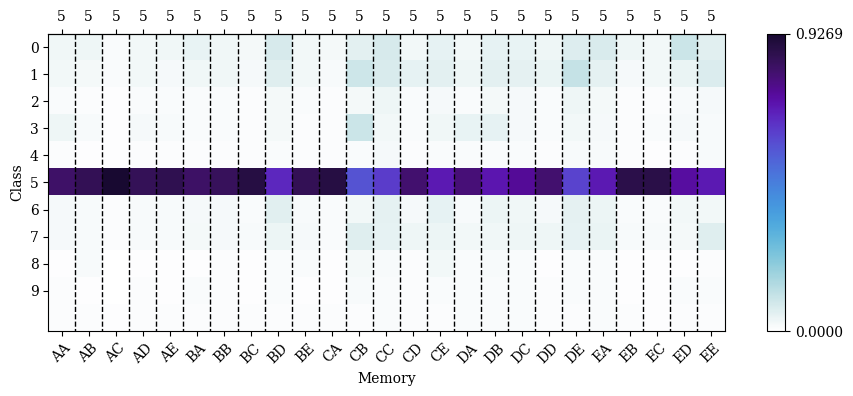

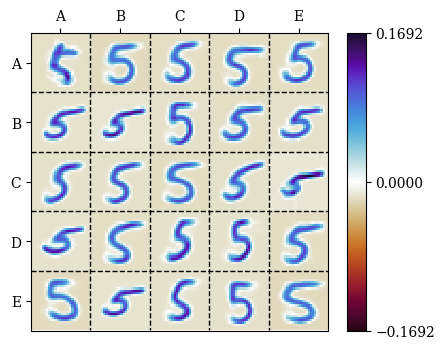

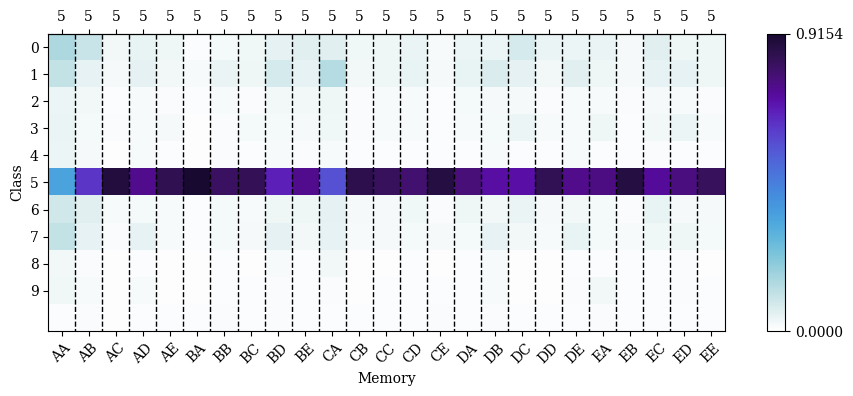

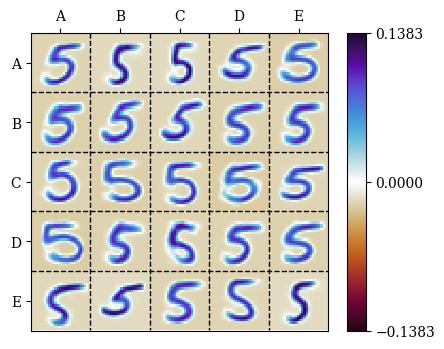

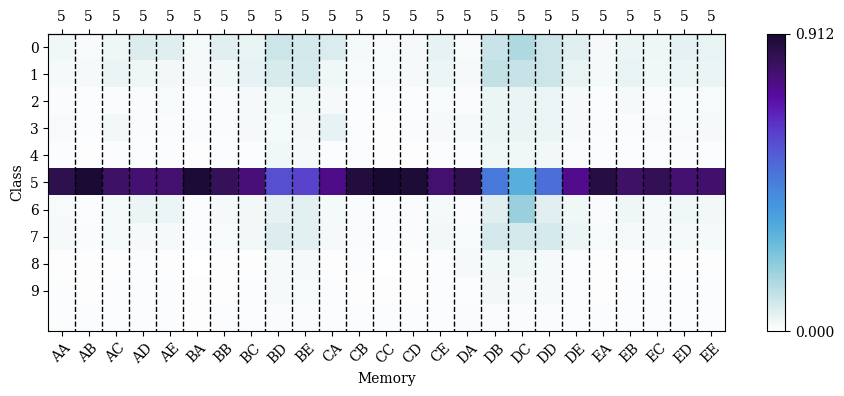

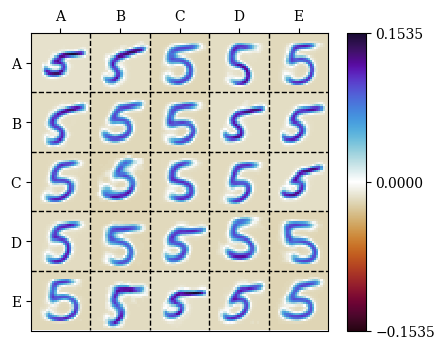

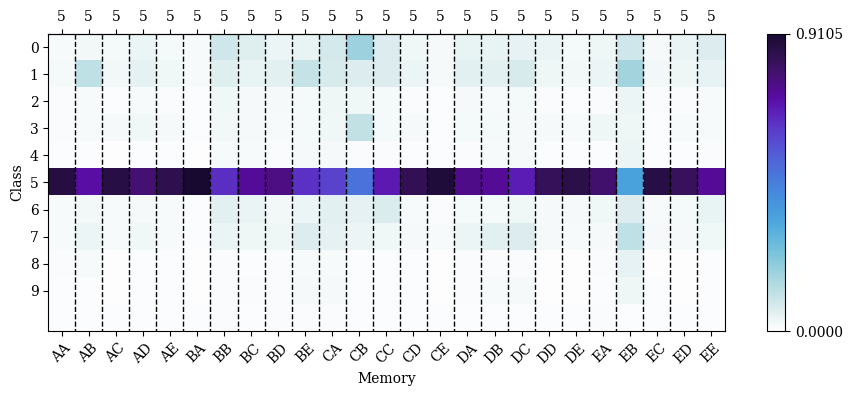

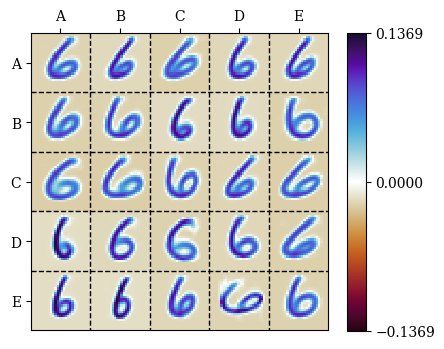

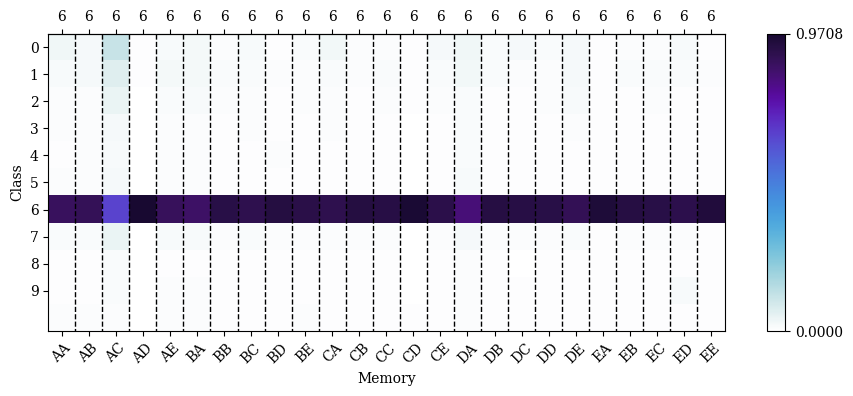

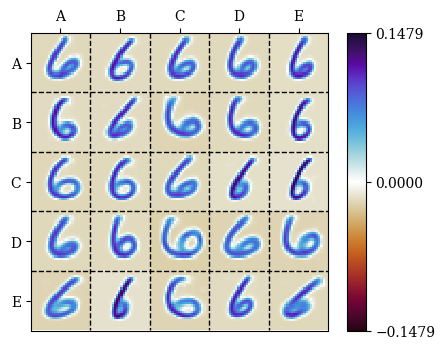

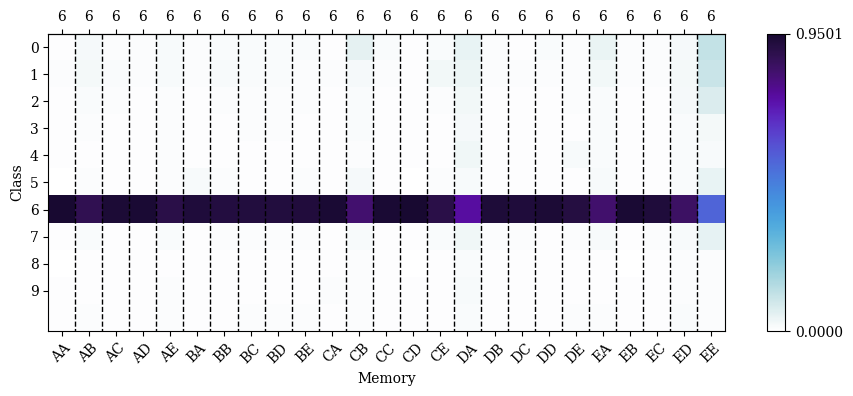

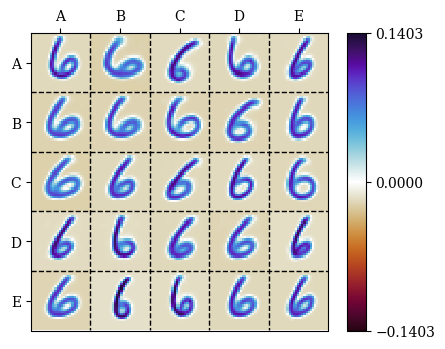

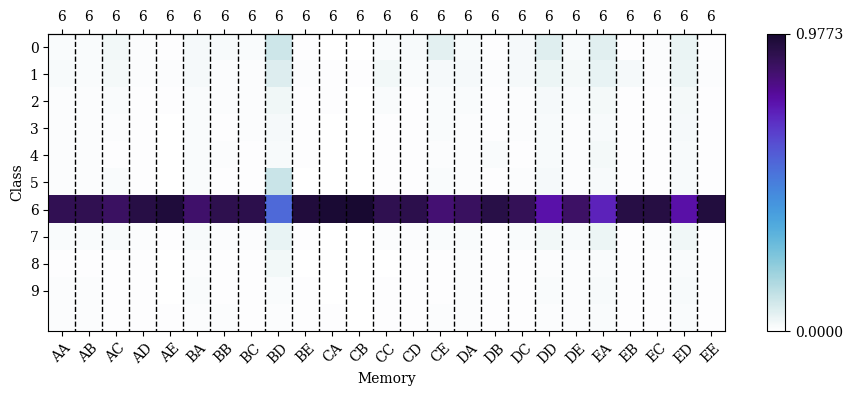

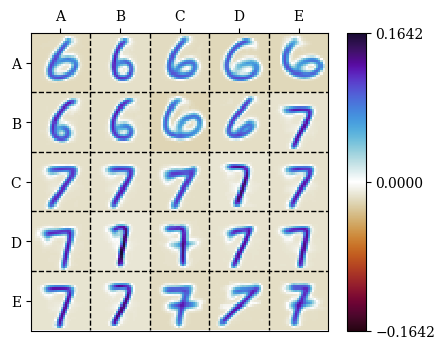

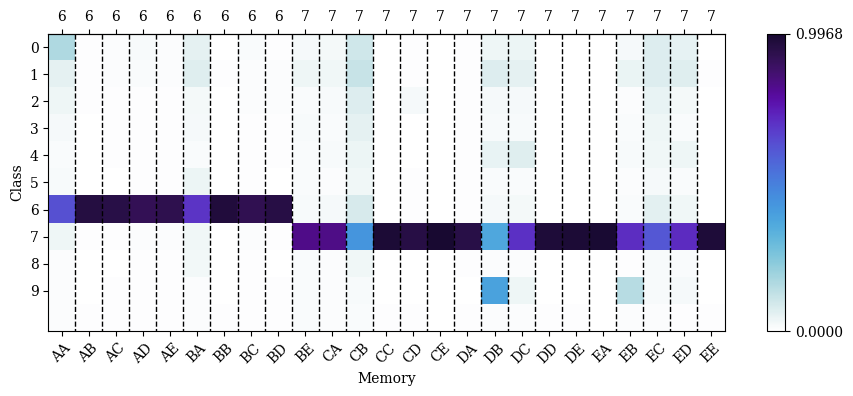

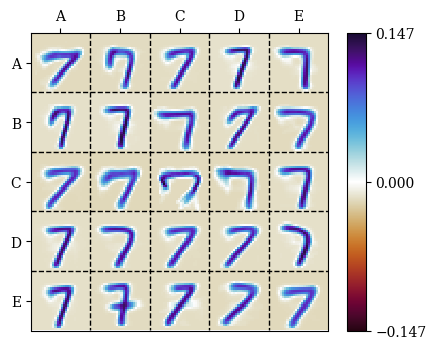

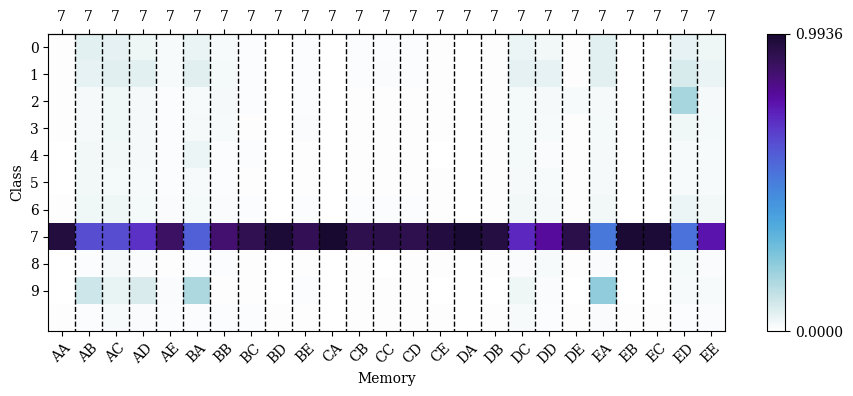

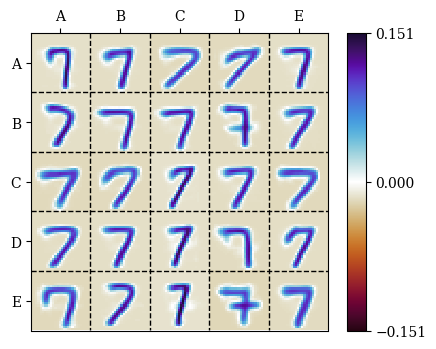

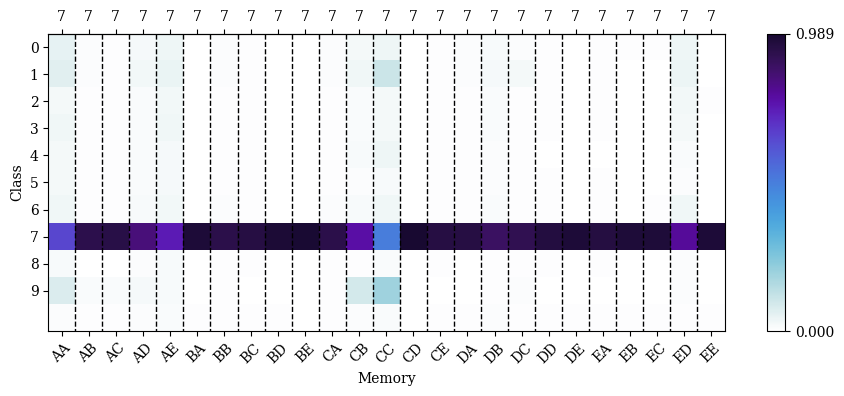

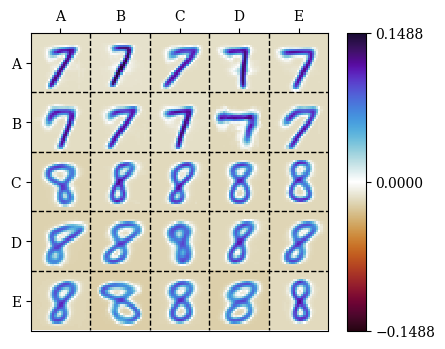

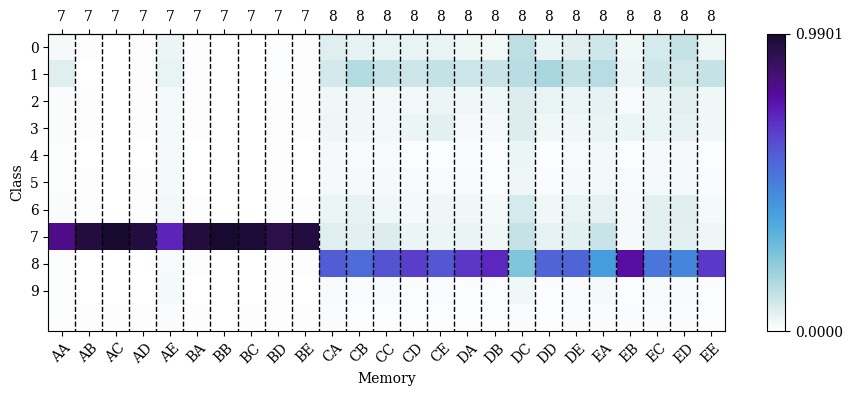

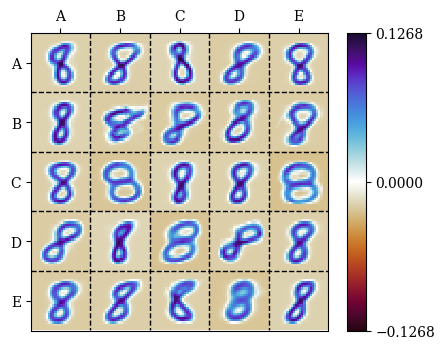

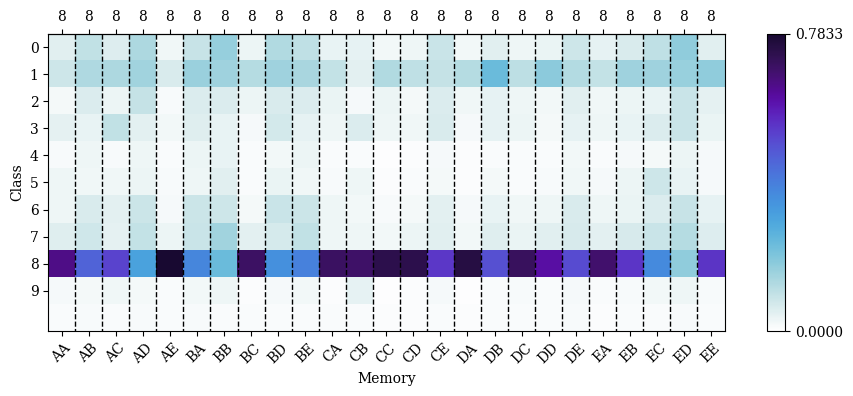

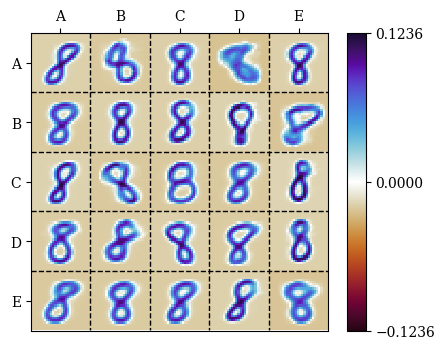

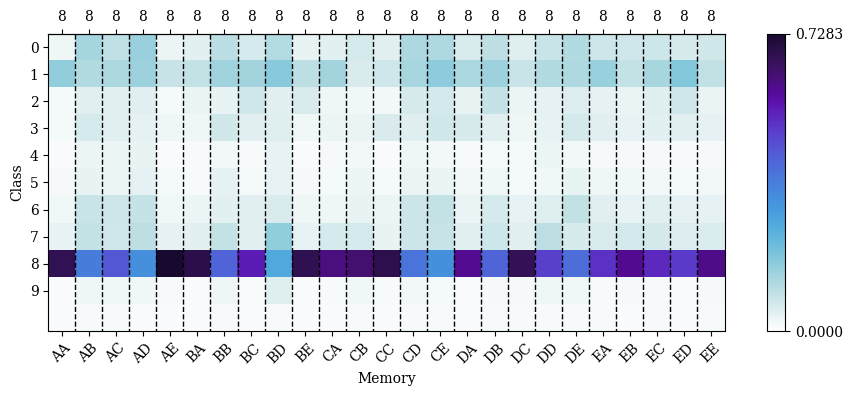

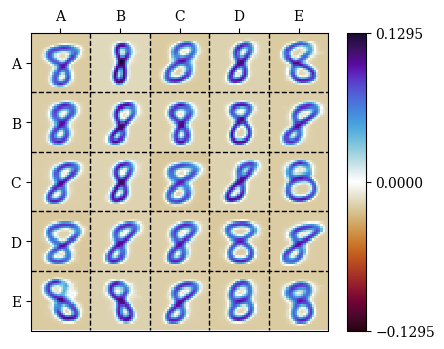

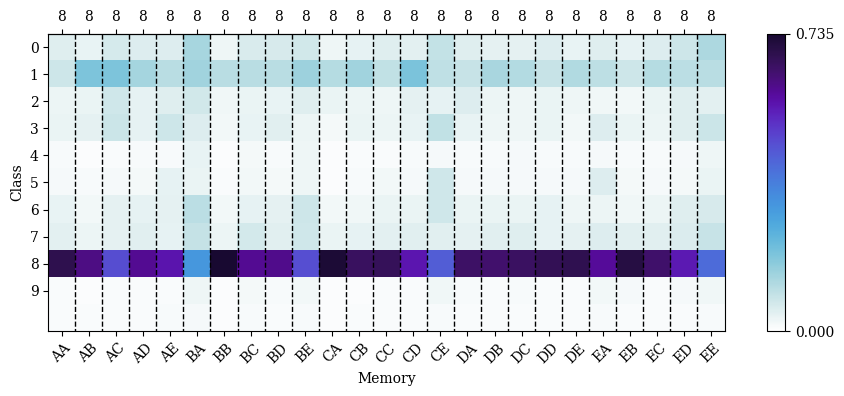

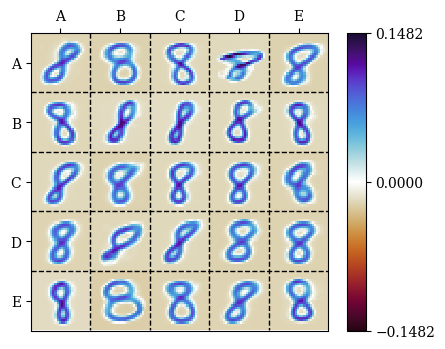

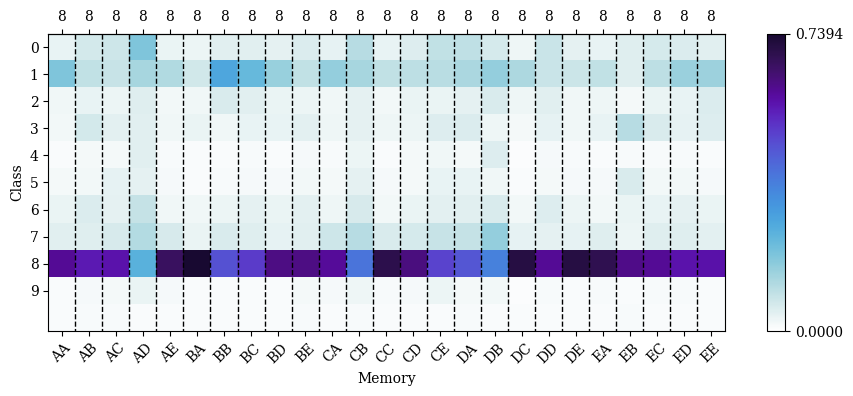

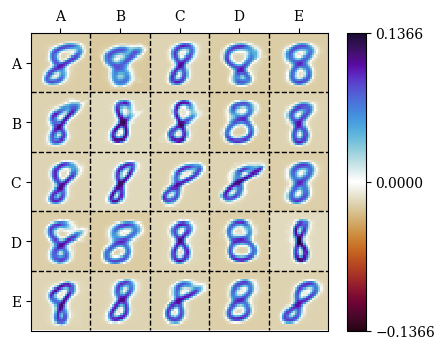

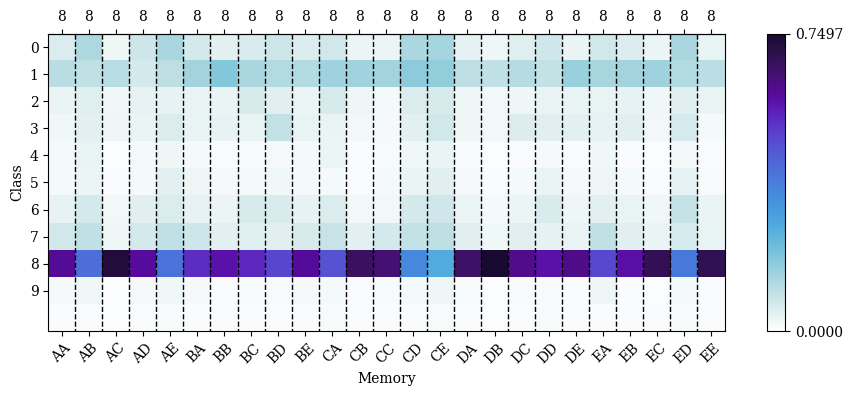

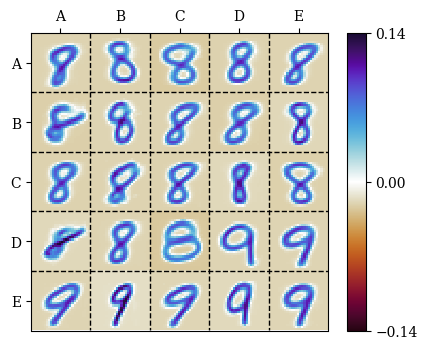

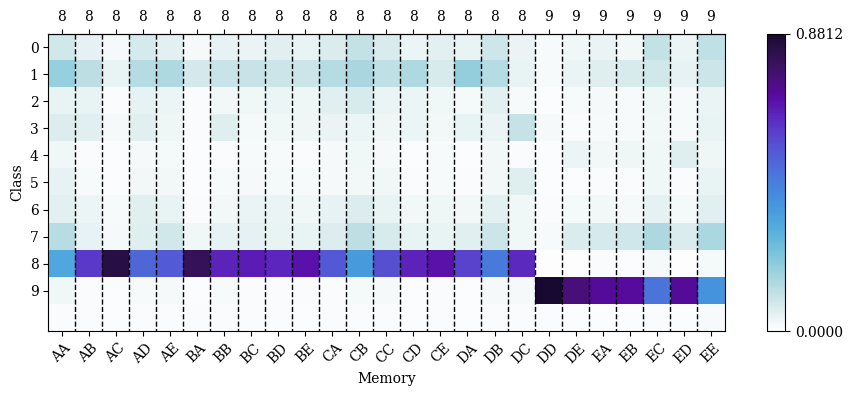

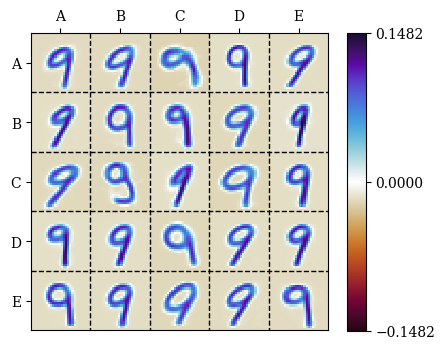

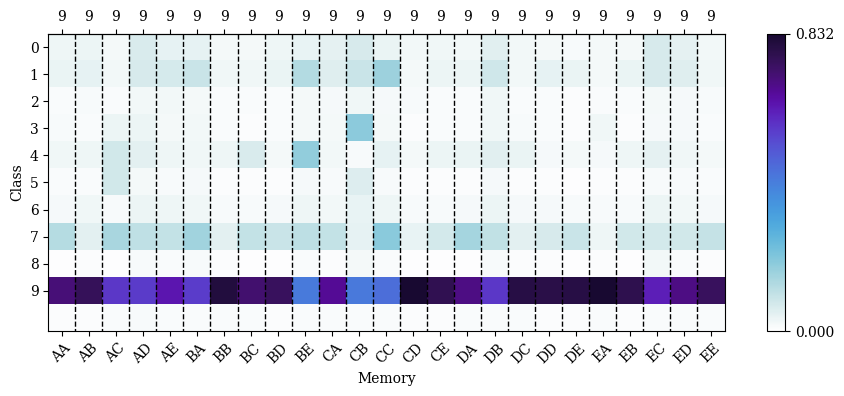

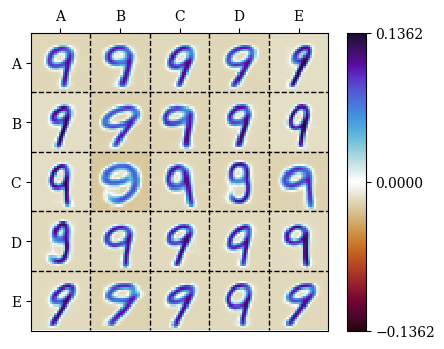

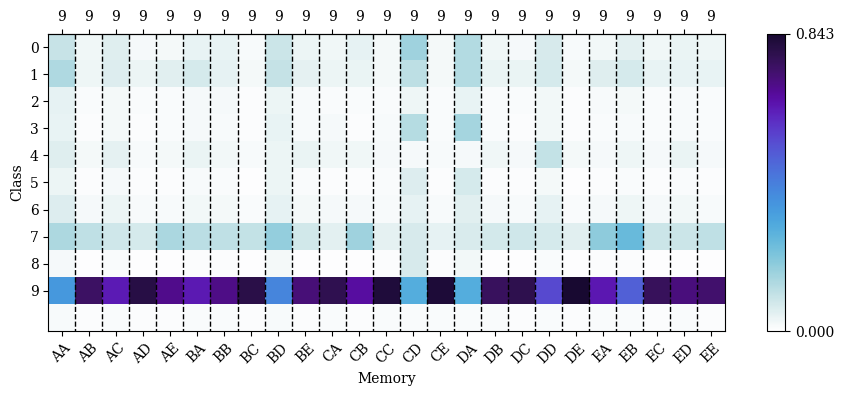

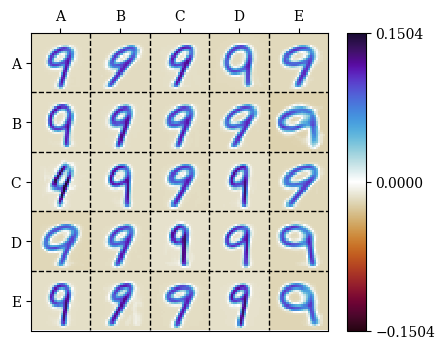

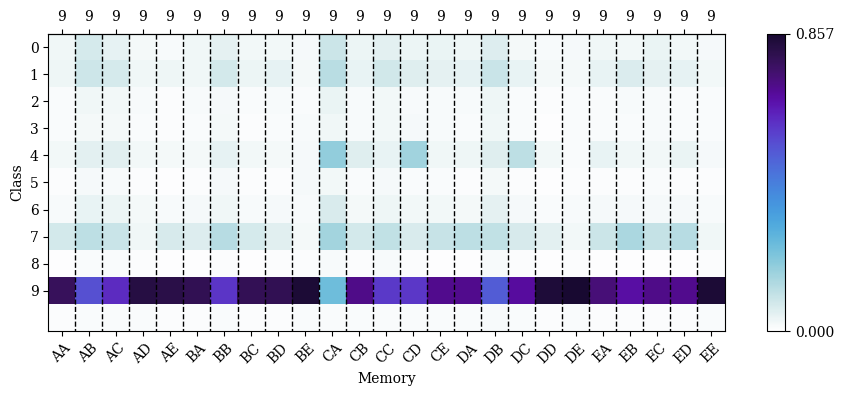

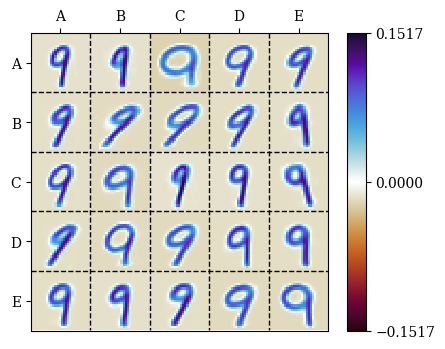

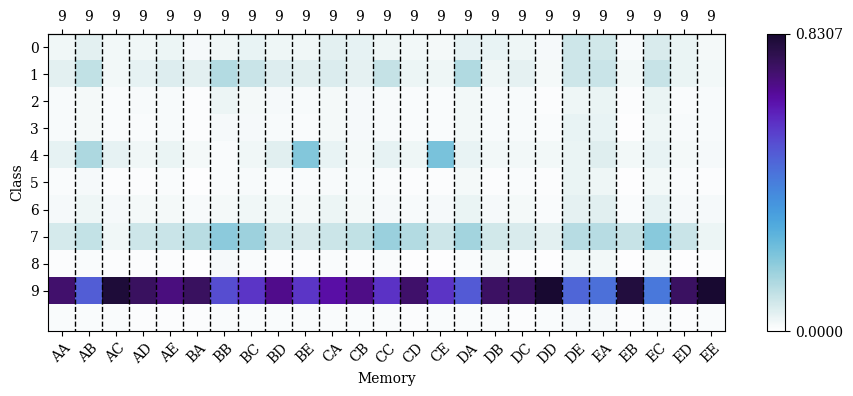

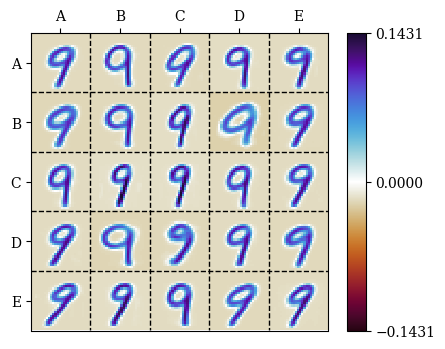

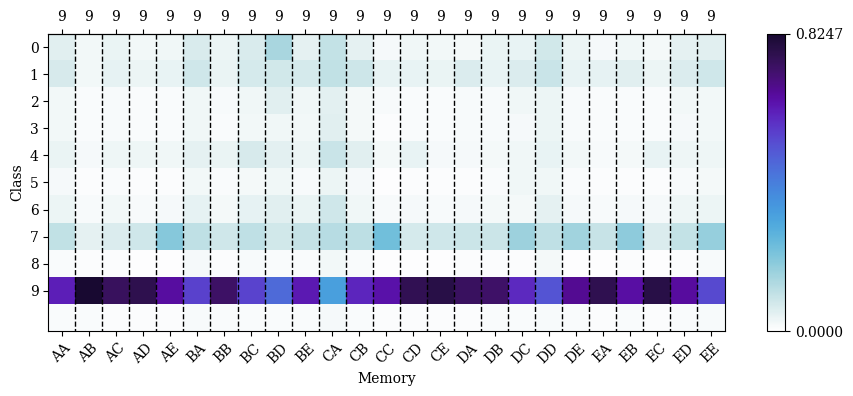

In [3]:
# Seed of random number generation for reproducibility
seed = 76986
np_rng = np.random.default_rng(seed)
np_seed, tf_seed = np_rng.integers(0, 2**63, size = 2)
np_rng = np.random.default_rng(np_seed)
tf.random.set_seed(tf_seed)

# Dataset and label softening
dataset = mnist
softening = 0.1

# Import data and reshape to vectors
x_train, y_train, x_test, y_test = data_proc.prepare_flat_data(dataset, normalize_data = True, softening = softening)

# Loss type (supervised or unsupervised)
loss = "supervised"

number_features = x_train.shape[1]
number_classes = y_train.shape[1]
batch_size = 1000

# Number of epochs of the memorization and splitting phases
# We increase the inverse temperature beta using an annealing (or cooling) schedule
# for a part of the memorization phase
number_memorization_epochs = 200
number_annealing_epochs = 100
number_splitting_epochs = 100

# Number of iterations of the Sinkhorn-Knopp algorithm to constrain the class weights
number_constraint_iterations = 10

# Maximum number of memories, initial number of memories
# and maximum number of splits of splitting steepest descent
max_number_memories = 1000
init_number_memories = 1000
number_splits = 0

# Hyperparameters of the callbacks (cooling schedule and early stopping)
beta_init = 8.
beta_final = 40.
slope = 4
beta_range = np.concatenate([np.array([beta_init]), np.full((number_splits + 1,), beta_final)])
patience = 1

# Optimizer hyperparameters
learning_rate = 0.1
momentum = 0.99

# Splitting steepest descent hyperparameters
max_fraction_eigvals = 1.
max_eigval = -0.001

# Boolean settings
normalize_online = False
save_model = True

# Calculate the class prior
y_hard = np.argmax(y_train, axis = 1)
counts_y = np.bincount(y_hard)
counts_y = np.concatenate([counts_y, np.array([0])])
prior_y = (1 - softening) * counts_y / np.sum(counts_y) + softening * 1/(number_classes + 1)

# Name of the model and what to record (see DAN_code.models.train_DAN for record options)
name = "DAN"
record = None

if record == "movies":
    try:
        fname = "./Data/Weights/%s_w_with_beta=%s_and_for_movies.npy" % (name, str(beta_final))
        os.remove(fname)
    except OSError:
        pass
    try:
        fname = "./Data/Weights/%s_g_with_beta=%s_and_for_movies.npy" % (name, str(beta_final))
        os.remove(fname)
    except OSError:
        pass

model = models.init_DAN(loss, beta_init, softening, number_features, init_number_memories, max_number_memories,
                        number_classes, number_constraint_iterations, learning_rate, momentum,
                        prior_y, normalize_online = normalize_online)

x_train = tf.convert_to_tensor(x_train, dtype = "float32")
y_train = tf.convert_to_tensor(y_train, dtype = "float32")

number_memories = init_number_memories
for split in range(number_splits + 1):
    
    beta_init = beta_range[split]
    
    beta_final = beta_range[split + 1]
    
    model = models.train_DAN(x_train, y_train, model, number_memorization_epochs,
                             number_annealing_epochs, batch_size, beta_final, slope, patience,
                             training_phase = "memorization", record = record, verbose = True)
    
    number_memories = model.get_DAN_layer(1).output_size
    max_number_memories = model.get_DAN_layer(1).max_output_size
    
    if number_memories == max_number_memories:
        print("Maximum number of memories reached, cannot split any further.")
        if save_model:
            models.save_DAN(model, beta_final, number_memories, split)
        break
    
    elif split == number_splits:
        print("Maximum number of splits reached, splitting will stop.")
        if save_model:
            models.save_DAN(model, beta_final, number_memories, split)
        break
    
    else:
        model = models.train_DAN(x_train, y_train, model, number_splitting_epochs,
                                 0, batch_size, beta_final, slope, patience,
                                 training_phase = "splitting", record = None, verbose = True)
        
        max_number_eigvals = int(np.rint(max_fraction_eigvals * number_memories))
        mask = models.calc_split_mask(x_train, y_train, model, max_number_eigvals,
                                      max_eigval, batch_size, adjust = True)
        
        if not k.any(mask):
            print("Found no favorable eigendirection to split, splitting will stop.")
            if save_model:
                models.save_DAN(model, beta_final, number_memories, split)
            break
        
        init.split_memories(model, mask, 0.25)
    
    w_cur = model.get_DAN_layer(1).get_weights()[0]
    g_cur = model.get_DAN_layer(2).get_weights()[0]
    
    w_plot = w_cur[:, : np.minimum(25, number_memories).astype("int")].T
    g_plot = g_cur[: np.minimum(25, number_memories).astype("int")].T
    
    res_plot.plot_images(w_plot)
    
    y_hard = np.argmax(model.predict(w_plot), axis = 1)
    res_plot.plot_labels(y_hard, g_plot)

models.compile_memorization_phase(model)
beta = beta_final
number_memories = max_number_memories
number_splits = np.ceil(np.log2(max_number_memories / init_number_memories)).astype("int")

model = models.load_DAN(beta, number_memories, number_splits)

# Get hard test labels and predictions
y_hard = np.argmax(y_test, axis = 1)
y_pred = np.argmax(model(x_test), axis = 1)

w = model.get_DAN_layer(1).get_weights()[0]
g = model.get_DAN_layer(2).get_weights()[0]

model.evaluate(tf.convert_to_tensor(x_test, dtype = "float32"),
               tf.convert_to_tensor(y_test, dtype = "float32"))

w_plot = w[:, : 25].T
g_plot = g[: 25].T

res_plot.plot_images(w_plot)

res_plot.plot_labels(np.argmax(model.predict(w_plot), axis = 1), g_plot)

res_test.sort_memories(model, number_memories)

### Fig. 2 and Fig. 5, 6, 7 and 8 of Appendix J: weights learned with unsupervised learning.

/home/rtheriault/Dense_Associative_Network/DAN_code/normalization.py:184: RuntimeWarning: invalid value encountered in divide
  directions = array / norms


Epoch 1/10
7776/7776 [==============================] - 31s 4ms/step - loss: -3.5291 - accuracy: 0.1445 - val_loss: -3.6271 - val_accuracy: 0.2936
Epoch 2/10
7776/7776 [==============================] - 72s 9ms/step - loss: -4.1218 - accuracy: 0.1600 - val_loss: -4.2064 - val_accuracy: 0.1488
Epoch 3/10
7776/7776 [==============================] - 55s 7ms/step - loss: -6.6786 - accuracy: 0.1638 - val_loss: -6.7272 - val_accuracy: 0.1563
Epoch 4/10
7776/7776 [==============================] - 48s 6ms/step - loss: -7.3777 - accuracy: 0.1589 - val_loss: -7.3977 - val_accuracy: 0.1566
Epoch 5/10
7776/7776 [==============================] - 48s 6ms/step - loss: -7.3946 - accuracy: 0.1586 - val_loss: -7.4143 - val_accuracy: 0.1571
Epoch 6/10
7776/7776 [==============================] - 47s 6ms/step - loss: -7.3947 - accuracy: 0.1590 - val_loss: -7.4144 - val_accuracy: 0.1556
Epoch 7/10
7776/7776 [==============================] - 48s 6ms/step - loss: -7.3947 - accuracy: 0.1587 - val_loss: -7

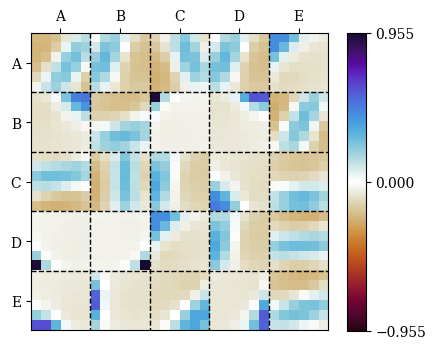

1/1 [==============================] - 0s 79ms/step


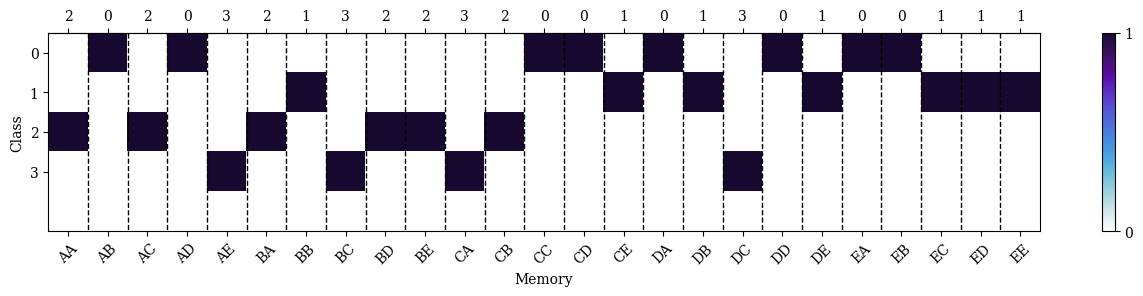

4/4 [==============================] - 0s 1ms/step


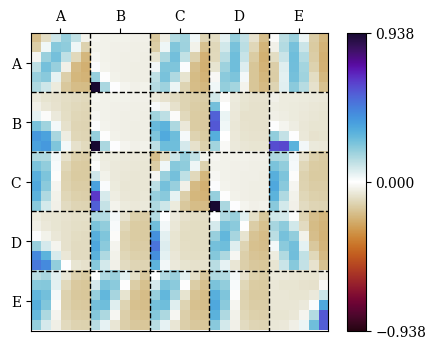

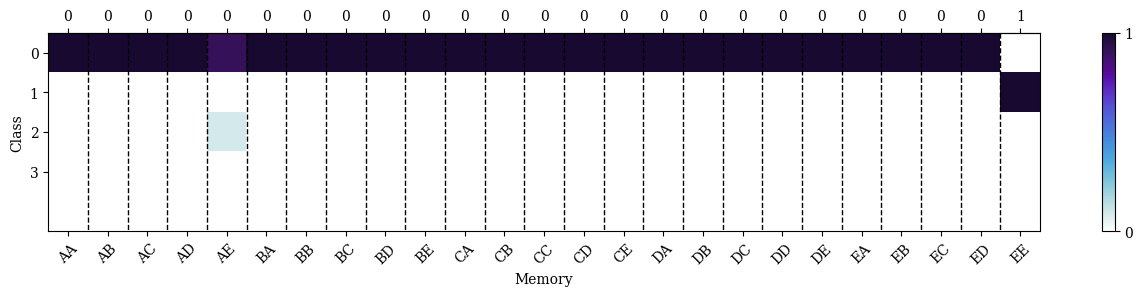

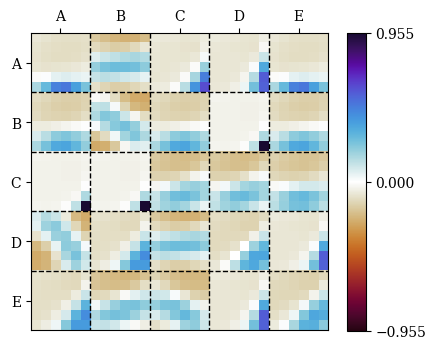

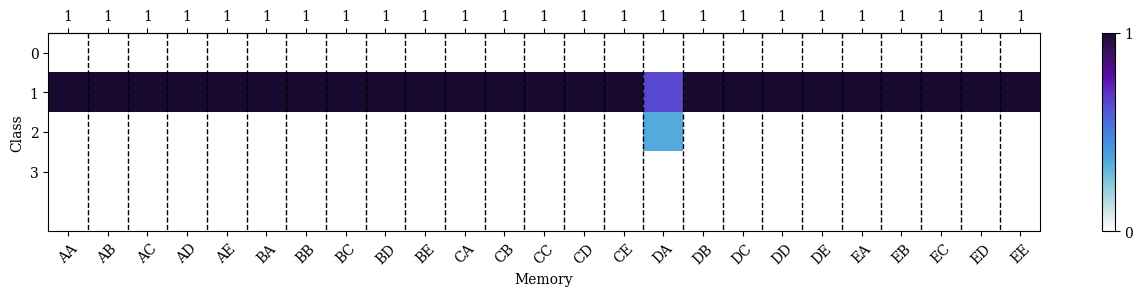

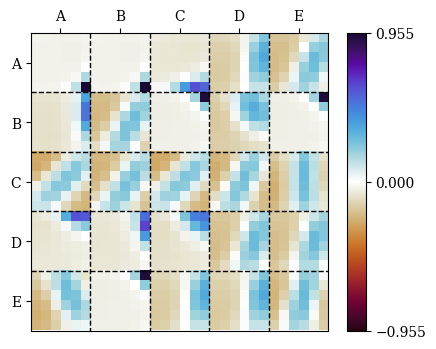

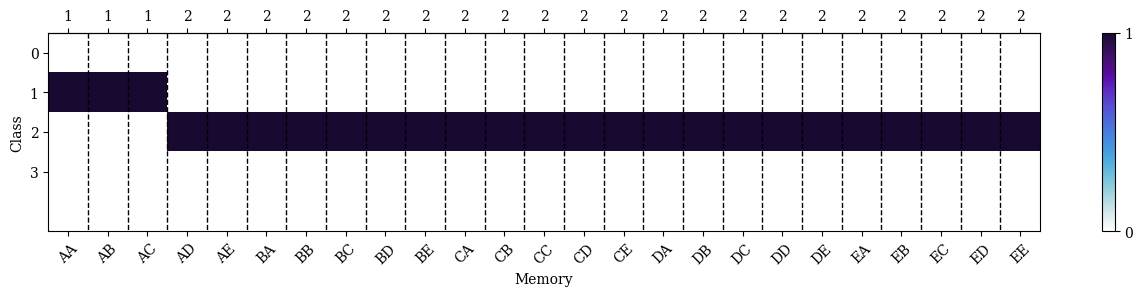

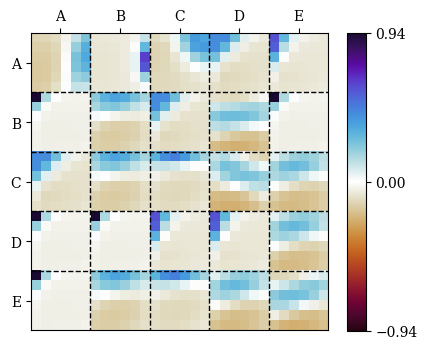

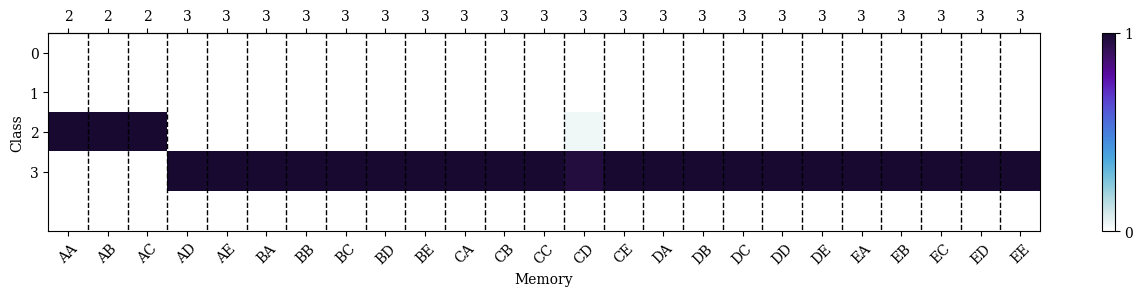

In [4]:
# Seed of random number generation for reproducibility
seed = 76986
np_rng = np.random.default_rng(seed)
np_seed, tf_seed = np_rng.integers(0, 2**63, size = 2)
np_rng = np.random.default_rng(np_seed)
tf.random.set_seed(tf_seed)

# Dataset and label softening
dataset = mnist
softening = 0.01

# Import data and reshape to vectors
x_train, y_train, x_test, y_test = data_proc.prepare_patch_data(dataset, normalize_data = True)

# Loss type (supervised or unsupervised)
loss = "unsupervised"

number_features = x_train.shape[1]
number_classes = 4
batch_size = 1000

# Number of epochs of the memorization and splitting phases
# We increase the inverse temperature beta using an annealing (or cooling) schedule
# for a part of the memorization phase
number_memorization_epochs = 10
number_annealing_epochs = 5
number_splitting_epochs = 10

# Number of iterations of the Sinkhorn-Knopp algorithm to constrain the class weights
number_constraint_iterations = 100

# Maximum number of memories, initial number of memories
# and maximum number of splits of splitting steepest descent
max_number_memories = 100
init_number_memories = 100
number_splits = 0

# Hyperparameters of the callbacks (cooling schedule and early stopping)
beta_init = 2.
beta_final = 10.
slope = 4
beta_range = np.concatenate([np.array([beta_init]), np.full((number_splits + 1,), beta_final)])
patience = 1

# Optimizer hyperparameters
learning_rate = 0.1
momentum = 0.99

# Splitting steepest descent hyperparameters
max_fraction_eigvals = 1.
max_eigval = -0.001

# Boolean settings
normalize_online = False
save_model = True

# Calculate the class prior
counts_y = np.array([110, 132, 121, 101])
counts_y = np.concatenate([counts_y, np.array([0])])
prior_y = (1 - softening) * counts_y / np.sum(counts_y) + softening * 1/(number_classes + 1)

# Name of the model and what to record (see DAN_code.models.train_DAN for record options)
name = "DAN"
record = None

if record == "movies":
    try:
        fname = "./Data/Weights/%s_w_with_beta=%s_and_for_movies.npy" % (name, str(beta_final))
        os.remove(fname)
    except OSError:
        pass
    try:
        fname = "./Data/Weights/%s_g_with_beta=%s_and_for_movies.npy" % (name, str(beta_final))
        os.remove(fname)
    except OSError:
        pass

model = models.init_DAN(loss, beta_init, softening, number_features, init_number_memories, max_number_memories,
                        number_classes, number_constraint_iterations, learning_rate, momentum,
                        prior_y, normalize_online = normalize_online)

x_train = tf.convert_to_tensor(x_train, dtype = "float32")
y_train = tf.convert_to_tensor(y_train, dtype = "float32")

number_memories = init_number_memories
for split in range(number_splits + 1):
    
    beta_init = beta_range[split]
    
    beta_final = beta_range[split + 1]
    
    model = models.train_DAN(x_train, y_train, model, number_memorization_epochs,
                             number_annealing_epochs, batch_size, beta_final, slope, patience,
                             training_phase = "memorization", record = record, verbose = True)
    
    number_memories = model.get_DAN_layer(1).output_size
    max_number_memories = model.get_DAN_layer(1).max_output_size
    
    if number_memories == max_number_memories:
        print("Maximum number of memories reached, cannot split any further.")
        if save_model:
            models.save_DAN(model, beta_final, number_memories, split)
        break
    
    elif split == number_splits:
        print("Maximum number of splits reached, splitting will stop.")
        if save_model:
            models.save_DAN(model, beta_final, number_memories, split)
        break
    
    else:
        model = models.train_DAN(x_train, y_train, model, number_splitting_epochs,
                                 0, batch_size, beta_final, slope, patience,
                                 training_phase = "splitting", record = None, verbose = True)
        
        max_number_eigvals = int(np.rint(max_fraction_eigvals * number_memories))
        mask = models.calc_split_mask(x_train, y_train, model, max_number_eigvals,
                                      max_eigval, batch_size, adjust = True)
        
        if not k.any(mask):
            print("Found no favorable eigendirection to split, splitting will stop.")
            if save_model:
                models.save_DAN(model, beta_final, number_memories, split)
            break
        
        init.split_memories(model, mask, 0.25)
    
    w_cur = model.get_DAN_layer(1).get_weights()[0]
    g_cur = model.get_DAN_layer(2).get_weights()[0]
    
    w_plot = w_cur[:, : np.minimum(25, number_memories).astype("int")].T
    g_plot = g_cur[: np.minimum(25, number_memories).astype("int")].T
    
    res_plot.plot_images(w_plot)
    
    y_hard = np.argmax(model.predict(w_plot), axis = 1)
    res_plot.plot_labels(y_hard, g_plot)

models.compile_memorization_phase(model)
beta = beta_final
number_memories = max_number_memories
number_splits = np.ceil(np.log2(max_number_memories / init_number_memories)).astype("int")

model = models.load_DAN(beta, number_memories, number_splits)

w = model.get_DAN_layer(1).get_weights()[0]
g = model.get_DAN_layer(2).get_weights()[0]
counts_memory = model.get_DAN_layer(2).counts_memory.numpy()

w_plot = w[:, : 25].T
g_plot = g[: 25].T

res_plot.plot_images(w_plot)

res_plot.plot_labels(np.argmax(model.predict(w_plot), axis = 1), g_plot)

res_test.sort_memories(model, number_memories)

del model

### Fig. 3, part 1: record weights to plot learning dynamics tree.

Weights to plot the learning dynamics tree are recorded by running the code cells below. The learning dynamics tree is plotted in the umap.ipynb notebook using the recorded weights.

Record weights as they are learned without splitting steepest descent

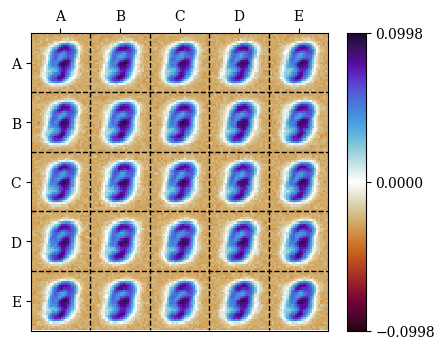

Epoch 1/600
10/10 [==============================] - 1s 17ms/step - loss: -8.0227 - accuracy: 0.1170
Epoch 2/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0235 - accuracy: 0.1170
Epoch 3/600
10/10 [==============================] - 0s 15ms/step - loss: -8.0250 - accuracy: 0.1170
Epoch 4/600
10/10 [==============================] - 0s 16ms/step - loss: -8.0269 - accuracy: 0.1170
Epoch 5/600
10/10 [==============================] - 0s 15ms/step - loss: -8.0295 - accuracy: 0.1170
Epoch 6/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0325 - accuracy: 0.1170
Epoch 7/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0360 - accuracy: 0.1170
Epoch 8/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0400 - accuracy: 0.1170
Epoch 9/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0445 - accuracy: 0.1170
Epoch 10/600
10/10 [==============================] - 0s 14ms/step - loss: -8.0494 - accura

In [5]:
# Seed of random number generation for reproducibility
seed = 2
tf.random.set_seed(seed)

# Dataset and label softening
dataset = mnist
softening = 0.1

# Import data and reshape to vectors
x_train, y_train, x_test, y_test = data_proc.prepare_flat_data(dataset, normalize_data = True, softening = softening)
x_train = x_train[: 1000]
y_train = y_train[: 1000]

# Loss type (supervised or unsupervised)
loss = "supervised"

number_features = x_train.shape[1]
number_classes = y_train.shape[1]
batch_size = 100

# Number of epochs of the memorization and splitting phases
# We increase the inverse temperature beta using an annealing (or cooling) schedule
# for a part of the memorization phase
number_memorization_epochs = 600
number_annealing_epochs = 300
number_splitting_epochs = 0

# Number of iterations of the Sinkhorn-Knopp algorithm to constrain the class weights
number_constraint_iterations = 10

# Maximum number of memories, initial number of memories
# and maximum number of splits of splitting steepest descent
max_number_memories = 400
init_number_memories = 400
number_splits = 0

# Hyperparameters of the callbacks (cooling schedule and early stopping)
beta_init = 8.
beta_final = 40.
beta_range = np.concatenate([np.array([beta_init]), np.full((number_splits + 1,), beta_final)])
slope = 2
patience = 2

# Optimizer hyperparameters
learning_rate = 0.1
momentum = 0.99

# Splitting steepest descent hyperparameters
max_fraction_eigvals = 1.
max_eigval = -0.001

# Boolean settings
normalize_online = False
save_model = True

# Calculate the class prior
y_hard = np.argmax(y_train, axis = 1)
counts_y = np.bincount(y_hard)
counts_y = np.concatenate([counts_y, np.array([0])])
prior_y = (1 - softening) * counts_y / np.sum(counts_y) + softening * 1/(number_classes + 1)

# Name of the model and what to record (see DAN_code.models.train_DAN for record options)
name = "DAN"
record = "weights_without_splitting"

if record is not None:
    if record[: 7] == "weights":
        try:
            fname = "./Data/Weights/%s_w_with_beta=%s_and_%s.npy" % (name, str(beta_final), record[8 :])
            os.remove(fname)
        except OSError:
            pass
        try:
            fname = "./Data/Weights/%s_g_with_beta=%s_and_%s.npy" % (name, str(beta_final), record[8 :])
            os.remove(fname)
        except OSError:
            pass
    
model = models.init_DAN(loss, beta_init, softening, number_features, init_number_memories, max_number_memories,
                        number_classes, number_constraint_iterations, learning_rate, momentum,
                        prior_y, normalize_online = normalize_online)

w = model.get_DAN_layer(1).get_weights()

w_init = np.mean(x_train, axis = 0, keepdims = True).T
w_init = w_init / np.sum(w_init**2, keepdims = True)**(1/2)
w_init = np.tile(w_init, reps = (1, init_number_memories))

w_init = init.random_vmf(w_init, eps**(-3/4))

w[0][:, : init_number_memories] = w_init

model.get_DAN_layer(1).set_weights(w)

w = model.get_DAN_layer(1).get_weights()[0]

w_plot = w[:, : 25].T

res_plot.plot_images(w_plot)

x_train = tf.convert_to_tensor(x_train, dtype = "float32")
y_train = tf.convert_to_tensor(y_train, dtype = "float32")

start_time = time.perf_counter()
for split in range(number_splits + 1):
    
    beta_init = beta_range[split]
    
    beta_final = beta_range[split + 1]
    
    model = models.train_DAN(x_train, y_train, model, number_memorization_epochs,
                             number_annealing_epochs, batch_size, beta_final, slope, patience,
                             training_phase = "memorization", record = record, verbose = True,
                             validation_split = 0)
    
    number_memories = model.get_DAN_layer(1).output_size
    max_number_memories = model.get_DAN_layer(1).max_output_size
    if number_memories == max_number_memories:
        print("Maximum number of memories reached, cannot split any further.")
        models.save_DAN(model, beta_final, number_memories, split)
        break
    
    elif split == number_splits:
        print("Maximum number of splits reached, splitting will stop.")
        models.save_DAN(model, beta_final, number_memories, split)
        break
    
    else:
        model = models.train_DAN(x_train, y_train, model, number_splitting_epochs,
                                 0, batch_size, beta_final, slope, patience,
                                 training_phase = "splitting", record = None, verbose = True,
                                 validation_split = 0)
        
        max_number_eigvals = int(np.rint(max_fraction_eigvals * number_memories))
        mask = models.calc_split_mask(x_train, y_train, model, max_number_eigvals,
                                      max_eigval, batch_size, adjust = True)
        
        if not k.any(mask):
            print("Found no favorable eigendirection to split, splitting will stop.")
            models.save_DAN(model, beta_final, number_memories, split)
            break
        
        init.split_memories(model, mask, 0.25)
    
    w_cur = model.get_DAN_layer(1).get_weights()[0]
    g_cur = model.get_DAN_layer(2).get_weights()[0]
    
    w_plot = w_cur[:, : 25].T
    g_plot = g_cur[: 25].T
    
    res_plot.plot_images(w_plot)
    
    y_hard = np.argmax(model.predict(w_plot), axis = 1)
    res_plot.plot_labels(y_hard, g_plot)

Record weights as they are learned with splitting steepest descent

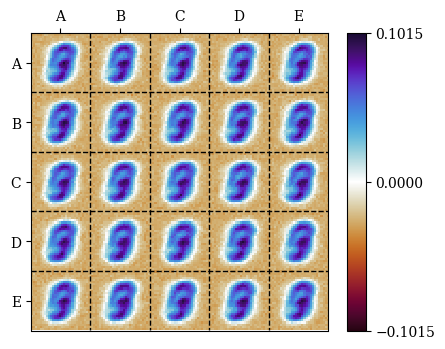

Epoch 1/300
10/10 [==============================] - 1s 15ms/step - loss: -6.6370 - accuracy: 0.1170
Epoch 2/300
10/10 [==============================] - 0s 13ms/step - loss: -6.6403 - accuracy: 0.1170
Epoch 3/300
10/10 [==============================] - 0s 12ms/step - loss: -6.6459 - accuracy: 0.1170
Epoch 4/300
10/10 [==============================] - 0s 16ms/step - loss: -6.6536 - accuracy: 0.1170
Epoch 5/300
10/10 [==============================] - 0s 18ms/step - loss: -6.6632 - accuracy: 0.1170
Epoch 6/300
10/10 [==============================] - 0s 17ms/step - loss: -6.6745 - accuracy: 0.1170
Epoch 7/300
10/10 [==============================] - 0s 17ms/step - loss: -6.6874 - accuracy: 0.1170
Epoch 8/300
10/10 [==============================] - 0s 17ms/step - loss: -6.7018 - accuracy: 0.1170
Epoch 9/300
10/10 [==============================] - 0s 11ms/step - loss: -6.7179 - accuracy: 0.1170
Epoch 10/300
10/10 [==============================] - 0s 12ms/step - loss: -6.7357 - accura

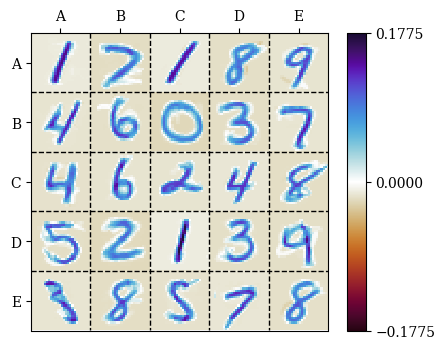

1/1 [==============================] - 0s 104ms/step


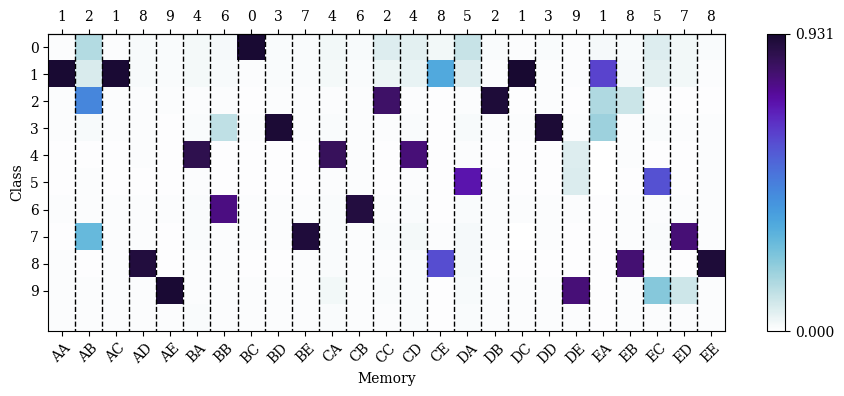

Epoch 1/300
10/10 [==============================] - 1s 15ms/step - loss: -34.3056 - accuracy: 0.9520
Epoch 2/300
10/10 [==============================] - 0s 15ms/step - loss: -34.3508 - accuracy: 0.9520
Epoch 3/300
10/10 [==============================] - 0s 14ms/step - loss: -34.4121 - accuracy: 0.9540
Epoch 4/300
10/10 [==============================] - 0s 15ms/step - loss: -34.4712 - accuracy: 0.9550
Epoch 5/300
10/10 [==============================] - 0s 16ms/step - loss: -34.5013 - accuracy: 0.9570
Epoch 6/300
10/10 [==============================] - 0s 16ms/step - loss: -34.5255 - accuracy: 0.9570
Epoch 7/300
10/10 [==============================] - 0s 16ms/step - loss: -34.5311 - accuracy: 0.9570
Epoch 8/300
10/10 [==============================] - 0s 15ms/step - loss: -34.5395 - accuracy: 0.9560
Epoch 9/300
10/10 [==============================] - 0s 16ms/step - loss: -34.5399 - accuracy: 0.9560
Epoch 10/300
10/10 [==============================] - 0s 15ms/step - loss: -34.544

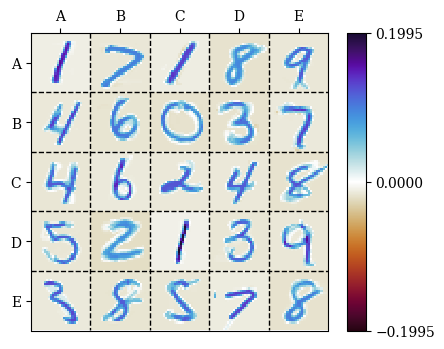

1/1 [==============================] - 0s 96ms/step


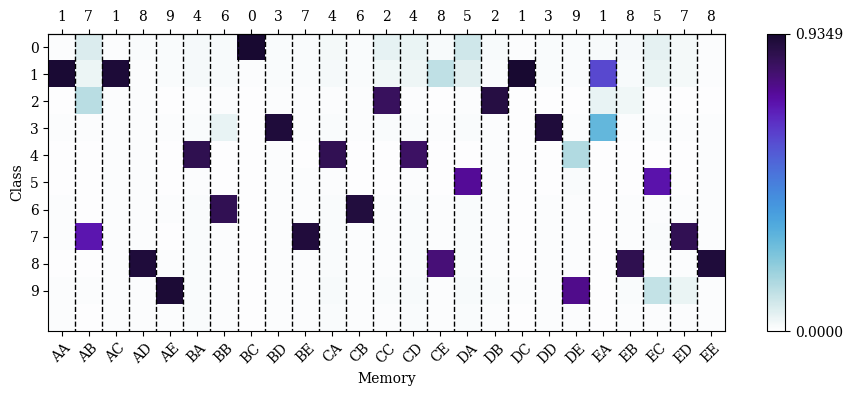

Epoch 1/300
10/10 [==============================] - 1s 16ms/step - loss: -36.1455 - accuracy: 0.9660
Epoch 2/300
10/10 [==============================] - 0s 16ms/step - loss: -36.1848 - accuracy: 0.9660
Epoch 3/300
10/10 [==============================] - 0s 15ms/step - loss: -36.2487 - accuracy: 0.9660
Epoch 4/300
10/10 [==============================] - 0s 16ms/step - loss: -36.3135 - accuracy: 0.9660
Epoch 5/300
10/10 [==============================] - 0s 15ms/step - loss: -36.3779 - accuracy: 0.9660
Epoch 6/300
10/10 [==============================] - 0s 14ms/step - loss: -36.4225 - accuracy: 0.9660
Epoch 7/300
10/10 [==============================] - 0s 15ms/step - loss: -36.4466 - accuracy: 0.9660
Epoch 8/300
10/10 [==============================] - 0s 14ms/step - loss: -36.4643 - accuracy: 0.9660
Epoch 9/300
10/10 [==============================] - 0s 16ms/step - loss: -36.4715 - accuracy: 0.9670
Epoch 10/300
10/10 [==============================] - 0s 15ms/step - loss: -36.477

In [6]:
# Seed of random number generation for reproducibility
seed = 2
tf.random.set_seed(seed)

# Dataset and label softening
dataset = mnist
softening = 0.1

# Import data and reshape to vectors
x_train, y_train, x_test, y_test = data_proc.prepare_flat_data(dataset, normalize_data = True, softening = softening)
x_train = x_train[: 1000]
y_train = y_train[: 1000]

# Loss type (supervised or unsupervised)
loss = "supervised"

number_features = x_train.shape[1]
number_classes = y_train.shape[1]
batch_size = 100

# Number of epochs of the memorization and splitting phases
# We increase the inverse temperature beta using an annealing (or cooling) schedule
# for a part of the memorization phase
number_memorization_epochs = 300
number_annealing_epochs = 150
number_splitting_epochs = 300

# Number of iterations of the Sinkhorn-Knopp algorithm to constrain the class weights
number_constraint_iterations = 10

# Maximum number of memories, initial number of memories
# and maximum number of splits of splitting steepest descent
max_number_memories = 400
init_number_memories = 100
number_splits = 14

# Hyperparameters of the callbacks (cooling schedule and early stopping)
beta_init = 8.
beta_final = 40.
beta_range = np.concatenate([np.array([beta_init]), np.full((number_splits + 1,), beta_final)])
slope = 2
patience = 2

# Optimizer hyperparameters
learning_rate = 0.1
momentum = 0.99

# Splitting steepest descent hyperparameters
max_fraction_eigvals = 1.
max_eigval = -0.001

# Boolean settings
normalize_online = False
save_model = True

# Calculate the class prior
y_hard = np.argmax(y_train, axis = 1)
counts_y = np.bincount(y_hard)
counts_y = np.concatenate([counts_y, np.array([0])])
prior_y = (1 - softening) * counts_y / np.sum(counts_y) + softening * 1/(number_classes + 1)

# Name of the model and what to record (see DAN_code.models.train_DAN for record options)
name = "DAN"
record = "weights_with_splitting"

if record is not None:
    if record[: 7] == "weights":
        try:
            fname = "./Data/Weights/%s_w_with_beta=%s_and_%s.npy" % (name, str(beta_final), record[8 :])
            os.remove(fname)
        except OSError:
            pass
        try:
            fname = "./Data/Weights/%s_g_with_beta=%s_and_%s.npy" % (name, str(beta_final), record[8 :])
            os.remove(fname)
        except OSError:
            pass
    
model = models.init_DAN(loss, beta_init, softening, number_features, init_number_memories, max_number_memories,
                        number_classes, number_constraint_iterations, learning_rate, momentum,
                        prior_y, normalize_online = normalize_online)

w = model.get_DAN_layer(1).get_weights()

w_init = np.mean(x_train, axis = 0, keepdims = True).T
w_init = w_init / np.sum(w_init**2, keepdims = True)**(1/2)
w_init = np.tile(w_init, reps = (1, init_number_memories))

w_init = init.random_vmf(w_init, eps**(-3/4))

w[0][:, : init_number_memories] = w_init

model.get_DAN_layer(1).set_weights(w)

w = model.get_DAN_layer(1).get_weights()[0]

w_plot = w[:, : 25].T

res_plot.plot_images(w_plot)

x_train = tf.convert_to_tensor(x_train, dtype = "float32")
y_train = tf.convert_to_tensor(y_train, dtype = "float32")

start_time = time.perf_counter()
for split in range(number_splits + 1):
    
    beta_init = beta_range[split]
    
    beta_final = beta_range[split + 1]
    
    model = models.train_DAN(x_train, y_train, model, number_memorization_epochs,
                             number_annealing_epochs, batch_size, beta_final, slope, patience,
                             training_phase = "memorization", record = record, verbose = True,
                             validation_split = 0)
    
    number_memories = model.get_DAN_layer(1).output_size
    max_number_memories = model.get_DAN_layer(1).max_output_size
    if number_memories == max_number_memories:
        print("Maximum number of memories reached, cannot split any further.")
        models.save_DAN(model, beta_final, number_memories, split)
        break
    
    elif split == number_splits:
        print("Maximum number of splits reached, splitting will stop.")
        models.save_DAN(model, beta_final, number_memories, split)
        break
    
    else:
        model = models.train_DAN(x_train, y_train, model, number_splitting_epochs,
                                 0, batch_size, beta_final, slope, patience,
                                 training_phase = "splitting", record = None, verbose = True,
                                 validation_split = 0)
        
        max_number_eigvals = int(np.rint(max_fraction_eigvals * number_memories))
        mask = models.calc_split_mask(x_train, y_train, model, max_number_eigvals,
                                      max_eigval, batch_size, adjust = True)
        
        if not k.any(mask):
            print("Found no favorable eigendirection to split, splitting will stop.")
            models.save_DAN(model, beta_final, number_memories, split)
            break
        
        init.split_memories(model, mask, 0.25)
    
    w_cur = model.get_DAN_layer(1).get_weights()[0]
    g_cur = model.get_DAN_layer(2).get_weights()[0]
    
    w_plot = w_cur[:, : 25].T
    g_plot = g_cur[: 25].T
    
    res_plot.plot_images(w_plot)
    
    y_hard = np.argmax(model.predict(w_plot), axis = 1)
    res_plot.plot_labels(y_hard, g_plot)

### Fig. 4: training time with and without splitting steepest descent.

User-defined parameters common to training with and without splitting steepest descent

Run this code cell first, then run either of the next two code cells to set the parameters for training with or without splitting steepest descent

In [3]:
# Seed of random number generation for reproducibility
seed = 2
np_rng = np.random.default_rng(seed)

# Dataset and label softening
dataset = mnist
softening = 0.1

# Import data and reshape to vectors
x_train, y_train, x_test, y_test = data_proc.prepare_flat_data(dataset, normalize_data = True, softening = softening)

# Loss type (supervised or unsupervised)
loss = "supervised"

number_features = x_train.shape[1]
number_classes = y_train.shape[1]
batch_size = 1000

# Number of iterations of the Sinkhorn-Knopp algorithm to constrain the class weights
number_constraint_iterations = 10

# Maximum number of splits of splitting steepest descent
number_splits = 14

# Hyperparameter values
beta_init = 8.
beta_final = 40.
slope = 4
beta_range = np.concatenate([np.array([beta_init]), np.full((number_splits + 1,), beta_final)])
patience = 1

# Optimizer hyperparameters
learning_rate = 0.1
momentum = 0.99

# Splitting steepest descent hyperparameters
max_fraction_eigvals = 1.
max_eigval = -0.001

# Boolean settings
normalize_online = False
save_model = True

# Calculate the class prior
y_hard = np.argmax(y_train, axis = 1)
counts_y = np.bincount(y_hard)
counts_y = np.concatenate([counts_y, np.array([0])])
prior_y = (1 - softening) * counts_y / np.sum(counts_y) + softening * 1/(number_classes + 1)

x_train = tf.convert_to_tensor(x_train, dtype = "float32")
y_train = tf.convert_to_tensor(y_train, dtype = "float32")

Parameter values used for training with splitting steepest descent

Change max_number_memories to choose which data point of Fig. 4 to reproduce

In [ ]:
max_number_memories = 1000
#max_number_memories = 1250
#max_number_memories = 1500
#max_number_memories = 1750
#max_number_memories = 2000

init_number_memories = 100

number_memorization_epochs = 100
number_annealing_epochs = 50
number_splitting_epochs = 100

Parameter values used for training without splitting steepest descent

Change max_number_memories to choose which data point of Fig. 4 to reproduce

In [ ]:
max_number_memories = 1000
#max_number_memories = 1250
#max_number_memories = 1500
#max_number_memories = 1750
#max_number_memories = 2000

init_number_memories = max_number_memories

number_memorization_epochs = 100 + max_number_memories // 10
number_annealing_epochs = (number_memorization_epochs + 1) // 2
number_splitting_epochs = 0

Run this code cell to estimate the accuracy and training time for the parameters set in the cells above

In [ ]:
number_repeats = 10

run_times = []
accuracies = []

for _ in range(number_repeats):
    run_time = np.inf
    np_seed, tf_seed = np_rng.integers(0, 2**63, size = 2)
    np_rng = np.random.default_rng(np_seed)
    tf.random.set_seed(tf_seed)
    
    #for _ in range(1):
    for _ in range(number_repeats):
        beta_init = beta_range[0]
        model = models.init_DAN(loss, beta_init, softening, number_features, init_number_memories, max_number_memories,
                                number_classes, number_constraint_iterations, learning_rate, momentum,
                                prior_y, normalize_online = normalize_online)

        start_time = time.perf_counter()
        for split in range(number_splits + 1):
            cur_split = split

            beta_final = beta_range[split + 1]

            model = models.train_DAN(x_train, y_train, model, number_memorization_epochs,
                                     number_annealing_epochs, batch_size, beta_final, slope, patience,
                                     training_phase = "memorization", record = None, verbose = False)
            
            number_memories = model.get_DAN_layer(1).output_size
            max_number_memories = model.get_DAN_layer(1).max_output_size

            if number_memories == max_number_memories:
                break

            elif split == number_splits:
                break

            else:
                model = models.train_DAN(x_train, y_train, model, number_splitting_epochs,
                                         0, batch_size, beta_final, slope, patience,
                                         training_phase = "splitting", record = None, verbose = False)

                max_number_eigvals = int(np.rint(max_fraction_eigvals * number_memories))
                mask = models.calc_split_mask(x_train, y_train, model, max_number_eigvals,
                                              max_eigval, batch_size, adjust = True)

                if not k.any(mask):
                    break

                init.split_memories(model, mask, 0.25)

        end_time = time.perf_counter()

        run_time = np.minimum(run_time, end_time - start_time)
    
    print(run_time)
    run_times.append(run_time)
    
    w_cur = model.get_DAN_layer(1).get_weights()[0]
    g_cur = model.get_DAN_layer(2).get_weights()[0]

    w_plot = w_cur[:, : 25].T
    g_plot = g_cur[: 25].T

    res_plot.plot_images(w_plot)

    y_hard = np.argmax(model.predict(w_plot), axis = 1)
    res_plot.plot_labels(y_hard, g_plot)

    models.compile_memorization_phase(model)

    accuracy = model.evaluate(x_test, y_test)[1]
    accuracies.append(accuracy)

beta = beta_final
number_splits = cur_split
with open("./Data/Performance/DAN_accuracy_and_run_time_with_beta=%s_and_%s_memories_for_%s_splits.npy"
          % (str(beta), str(number_memories), str(number_splits)), "wb") as f:
    np.save(f, np.array(run_times))
    np.save(f, np.array(accuracies))

Plotting

Assumes that the accuracy and training time were already calculated and saved using the code cells above

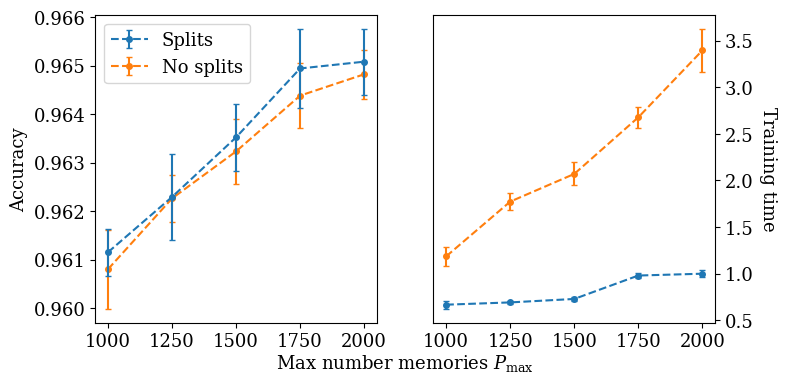

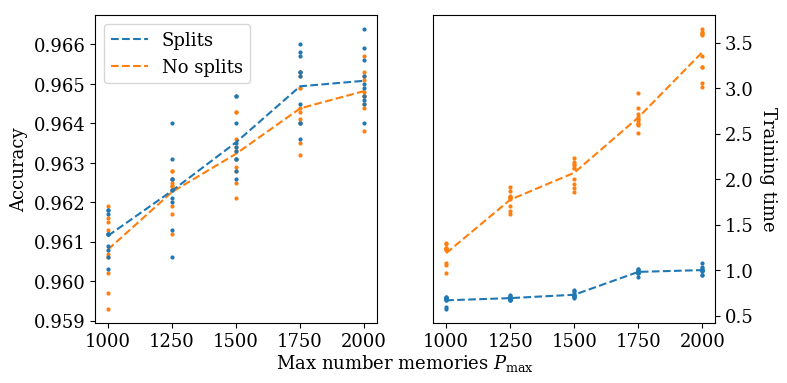

In [2]:
beta = 40.

number_memories_range = [1000, 1250, 1500, 1750, 2000]
number_splits_range = [4, 4, 4, 5, 5]

res_plot.plot_accuracy_and_runtime(beta, number_memories_range, number_splits_range)